# 5 — Regresión Lasso y coordinate descent

📓 [Notebook de clase](../raw/5_regresion_lineal_regularizacion_lasso.ipynb) · ✏️ [Ejercicios](../exercises/5_regresion_lineal_regularizacion_lasso.ipynb) · 📕 *ESL* (Hastie, Tibshirani & Friedman) como referencia principal

> **TL;DR**
>
> - Lasso es Ridge cambiando el cuadrado por el módulo: en lugar de $\lambda \sum \beta_j^2$ penaliza $\lambda \sum |\beta_j|$. Ese cambio de exponente parece cosmético y no lo es: rompe la solución cerrada y, en cambio, regala **selección de variables**.
> - No hay fórmula tipo $(\mathbf{X}^T\mathbf{X} + \lambda I)^{-1}\mathbf{X}^T\mathbf{y}$ para Lasso, porque $|\beta_j|$ no es derivable en cero. Hay que optimizar numéricamente: *coordinate descent* (el default de `scikit-learn`) o LARS.
> - *Coordinate descent* resuelve $p$ problemas de una variable, uno por vez, en ronda. Cada problema de una variable **sí** tiene solución cerrada: $\hat\beta_j = S(a_j, \lambda)$, con $a_j$ la correlación del residuo parcial con la columna $j$.
> - $S(t,\lambda) = \text{sign}(t)\,(|t| - \lambda)_+$ es el *soft-thresholding*: corre $t$ hacia el cero una distancia $\lambda$, y si $|t| \le \lambda$ lo **clava en cero exacto**. Ahí nace la esparsidad.
> - Ridge y Lasso son el caso $q=2$ y $q=1$ de la familia $\lambda \sum |\beta_j|^q$. $q = 1$ es el $q$ más chico que todavía da un problema **convexo**: la frontera exacta entre "tiene esquinas" (selecciona) y "se puede resolver con garantías".

## 🗺️ Mapa de la clase

| Bloque de la clase | Celdas | Dónde lo explico |
|--------------------|--------|------------------|
| Regresión Lineal › Bibliografía: | 0 | §1 |
| Repaso: Métodos de regularización | 1 | §1 |
| Repaso: Regresión Ridge | 2–6 | §2 |
| Regresión Lasso | 7–8 | §3 |
| Coordinate descent (soft-thresholding) | 9–12 | §4 |
| Coordinate descent (el esquema del algoritmo) | 13–14 | §5 |
| Coordinate descent (la cuenta: reducir el costo) | 15–16 | §6 |
| Coordinate descent (despejar $\beta_j$ y el caso $\beta_j = 0$) | 17–21 | §7 |
| Regresión Lasso (geometría L1 vs L2) | 22 | §8 |
| Regresión Ridge y Lasso › Formulaciones generales | 23 | §9 |
| Ejercicios | 24 | 🎯 Centros |


In [1]:
# Setup — estilo único para todos los gráficos de la notebook
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## 0. Notación y convenciones

Esta clase introduce tres cosas nuevas de notación y **cambia el significado de $\lambda$ a mitad de camino sin avisar**. Si no dejamos eso ordenado ahora, la cuenta larga de §6 y §7 se vuelve imposible de seguir.

| Símbolo | Cómo se lee | Qué es |
|---|---|---|
| $\hat\beta^{lasso}$ | "beta sombrero lasso" | el vector de coeficientes **estimados** minimizando el costo con penalización L1 |
| $\lambda$ | "lambda" | el parámetro de regularización. Cuánto te cobra el modelo por cada unidad de coeficiente |
| $\tilde\beta_k$ | "beta tilde sub k" | el valor **actual, provisorio** del coeficiente $k$ dentro del algoritmo iterativo. No es el óptimo: es lo que tenemos en la mano en esta ronda |
| $\tilde y_i$ | "y tilde sub i" | la predicción para la observación $i$ usando todos los coeficientes **menos** el $j$ que estamos por actualizar |
| $y_i - \tilde y_i$ | — | el **residuo parcial**: lo que queda sin explicar cuando saco de la predicción la contribución de $\beta_j$ |
| $S(t, \lambda)$ | "ese de te, lambda" | la función *soft-thresholding*. Es la protagonista de la clase |
| $(u)_+$ | "u más" | la parte positiva: $\max(0, u)$. Si $u$ es negativo, da cero |
| $q$ | "cu" | el exponente de la penalización en la familia general $\lambda \sum |\beta_j|^q$ |

### Los predictores están estandarizados

Toda la clase asume que las columnas de $\mathbf{X}$ están **estandarizadas** y que $\mathbf{y}$ está **centrada**. Concretamente:

$$\frac{1}{N}\sum_{i=1}^{N} x_{ij} = 0, \qquad \frac{1}{N}\sum_{i=1}^{N} x_{ij}^2 = 1 \quad \text{(o sea } \textstyle\sum_i x_{ij}^2 = N), \qquad \frac{1}{N}\sum_{i=1}^{N} y_i = 0$$

Eso no es un detalle estético, y son dos supuestos que hacen dos trabajos distintos:

- **Centrar $\mathbf{y}$ y las columnas** permite **olvidarse de $\beta_0$**. Con todo centrado, el intercepto óptimo es cero, así que desaparece de las cuentas. Si no centrás, $\beta_0$ se queda ahí y, peor, la penalización empieza a castigarlo: el modelo te recorta el promedio de $\mathbf{y}$, que no tiene nada que ver con complejidad. **$\beta_0$ nunca se penaliza.**
- **Poner todas las columnas en la misma escala** hace que $\lambda$ signifique lo mismo para todos los coeficientes. La penalización L1 suma $|\beta_j|$ de todas las variables juntas; si una está en metros y otra en kilómetros, sus coeficientes viven en escalas distintas y $\lambda$ castiga mucho más a una que a otra. El modelo terminaría "seleccionando" por unidad de medida.
- Además, gracias a $\sum_i x_{ij}^2 = N$, en §6 se nos va a cancelar un término entero. Es el supuesto que hace que la fórmula final quede tan corta.

Ojo con un detalle numérico: "varianza 1" acá significa dividir por $\sqrt{\frac{1}{N}\sum (x_{ij} - \bar x_j)^2}$, es decir `X.std(axis=0)` de NumPy (denominador $N$), no el $N-1$ de `pandas`. Si usás $N-1$, $\sum_i x_{ij}^2 = N-1$ y la fórmula final queda con un factor colgado.

### ⚠️ El salto de notación con $\lambda$

Esto es lo más traicionero de la clase. Mirá las dos formas en que aparece el mismo problema:

| Dónde | Función de costo | Qué es $\lambda$ ahí |
|---|---|---|
| Celdas 7 y 13 (y 📕 ESL §3.4.2) | $\sum_{i=1}^{N} (y_i - \sum_j x_{ij}\beta_j)^2 + \lambda \sum_j |\beta_j|$ | penalización sobre la **suma** de cuadrados |
| Celda 15 en adelante | $\frac{1}{2N} \sum_{i=1}^{N} (y_i - \tilde y_i - x_{ij}\beta_j)^2 + \lambda |\beta_j|$ | penalización sobre el **promedio** de cuadrados (dividido 2) |

Son el mismo problema, pero **el $\lambda$ de la segunda fila no es el mismo número que el de la primera**. Si a la primera la multiplicás entera por $\frac{1}{2N}$, el punto que la minimiza no cambia (multiplicar una función por una constante positiva no mueve su mínimo), pero el coeficiente de la penalización pasa a ser $\frac{\lambda}{2N}$. La clase lo dice de costado —*"cualquier constante multiplicativa que agreguemos en el primer término puede ser eventualmente absorbida en $\lambda$"*— y sigue escribiendo $\lambda$ para las dos cosas.

La traducción, entonces, es:

$$\lambda_{\text{celda 15}} = \frac{\lambda_{\text{celda 7}}}{2N}$$

**De acá en adelante, cuando escriba $\lambda$ sin aclarar, es el de la celda 15** (convención $\frac{1}{2N}$), porque es el que aparece en la fórmula del *soft-thresholding* y es exactamente el `alpha` de `sklearn.linear_model.Lasso`. Lo vamos a verificar numéricamente en §7.


## 1. Por qué regularizamos, en dos frases

📓 celdas 0–1 · 📕 ESL §3.4

### La idea en criollo

Pensá en un presupuesto de obra. Le pedís a un arquitecto que te diseñe la casa que mejor entre en el terreno, y le das plata infinita. Te va a entregar algo que calza perfecto con cada irregularidad del lote: un recoveco acá, un ángulo raro allá. Ahora comprás el terreno de al lado, casi idéntico, y esa casa no sirve: estaba ajustada a los detalles del primero.

Regularizar es darle al arquitecto un presupuesto **acotado**. Con menos plata no puede seguir cada irregularidad, así que se ve forzado a entregar algo más liso —y eso liso, paradójicamente, le calza mejor al terreno de al lado.

> **Dónde se rompe la analogía.** El presupuesto de obra es una restricción que el arquitecto no puede violar. Acá, en la forma lagrangiana, $\lambda$ no es un techo: es un **precio**. El modelo puede gastar todo lo que quiera en coeficientes grandes si el ajuste lo compensa; lo que hace $\lambda$ es cobrárselo. La versión "techo" también existe —es la formulación con restricción $\sum_j |\beta_j| \le t$ de §9— y las dos son equivalentes, pero no son la misma cuenta.

### Formalizándolo

La celda 1 da las **dos motivaciones** que la cátedra usa para justificar todos los métodos de regularización:

**1. Multicolinealidad.** Cuando las columnas de $\mathbf{X}$ están muy correlacionadas, $\mathbf{X}^T\mathbf{X}$ está *casi* singular: tiene autovalores cercanos a cero. Su inversa tiene entonces entradas enormes, y como

$$\hat\beta^{ols} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

cualquier ruido chiquito en $\mathbf{y}$ se te amplifica en $\hat\beta$. Los coeficientes salen gigantes, con signos que no tienen sentido, y cambian por completo si sacás una observación. El ajuste puede ser buenísimo; los coeficientes, basura.

**2. Gauss–Markov.** El teorema dice que OLS es el **mejor estimador lineal insesgado** (BLUE, por *best linear unbiased estimator*): entre todos los estimadores que son lineales en $\mathbf{y}$ y que no tienen sesgo, OLS es el de menor varianza. Fijate en la letra chica: *entre los insesgados*. No dice que sea el mejor, punto. Si aceptás meterle un poco de sesgo a propósito, podés bajar la varianza tanto que el error total —sesgo² + varianza— te quede **más chico** que el de OLS.

Ridge y Lasso hacen exactamente eso: son estimadores **sesgados** a propósito. Cambian un poco de sesgo por mucha varianza menos.

La clase avisa que Gauss–Markov lo van a ver bien después de sesgo–varianza, así que acá lo tomamos como el motivo de fondo y seguimos. El hilo completo está en 📕 ESL §3.2.2 (el teorema) y §7.3 (la descomposición sesgo–varianza que lo vuelve accionable).

### ¿Por qué nos importa?

Porque define qué estamos buscando. Si lo que querés es el **mejor ajuste sobre los datos que tenés**, regularizar es sabotearte: OLS minimiza el $RSS$ de entrenamiento y cualquier $\lambda > 0$ te lo va a empeorar. Regularizar solo tiene sentido si lo que te importa es una de estas dos cosas:

- **predecir bien sobre datos que todavía no viste**, o
- **interpretar** los coeficientes: saber qué variables importan y con qué signo.

Lasso, como vamos a ver, es particularmente bueno en la segunda, porque no se limita a encoger coeficientes: **apaga** los que no aportan. Te devuelve un modelo con menos variables, y un modelo con 4 variables se puede explicar; uno con 400 no.

### Bibliografía de la clase

La celda 0 lista lo que la cátedra usa para todo el bloque de regresión lineal:

- 📘 Bishop, cap. 3 (Ridge y Lasso aparecen en §3.1.4 como *regularized least squares*).
- 📕 ESL, cap. 3 (el bloque de regularización es §3.4; Lasso en particular, §3.4.2 y §3.4.3).
- Hoerl & Kennard (1970) — el paper original de Ridge.
- **Tibshirani (1996), *Regression Shrinkage and Selection via the Lasso*** — el paper original de Lasso, y el Ejercicio 1 de esta clase.
- Zou & Hastie (2005) — Elastic Net, que combina las dos penalizaciones. No lo vemos en esta clase, pero es la respuesta natural al problema que Lasso tiene con variables correlacionadas (el Ejercicio 3 te va a hacer tocar ese problema con la mano).


## 2. Repaso de Ridge: la solución cerrada y el encogimiento suave

📓 celdas 2–6 · 📕 ESL §3.4.1 · 📘 Bishop §3.1.4

Este es el repaso de la clase 4 ([`4_regresion_lineal_regularizacion_ridge`](4_regresion_lineal_regularizacion_ridge.ipynb)). Lo recorremos rápido, pero con un objetivo puntual: **quedarnos con las dos propiedades de Ridge que Lasso va a romper**. Sin esas dos, el resto de la clase no tiene contra qué comparar.

### La idea en criollo

Ridge le pone al modelo un impuesto proporcional al **cuadrado** de cada coeficiente. Un coeficiente de 10 no te cuesta 10 veces más que uno de 1: te cuesta 100 veces más. Es un impuesto que se ensaña con los grandes y casi no mira a los chicos: bajar un coeficiente de 10 a 9 te ahorra 19 unidades de penalización, bajarlo de 1 a 0 te ahorra 1.

Esa última frase es la clave de toda la clase, y conviene masticarla ahora: **para Ridge, llevar un coeficiente chiquito hasta cero exacto casi no vale la pena**. El ahorro tiende a cero justo cuando el coeficiente tiende a cero.

> **Dónde se rompe la analogía.** Un impuesto progresivo se calcula sobre cada contribuyente por separado y a nadie le cambia la declaración porque su vecino gane más. Acá los coeficientes **no son independientes**: el castigo se reparte entre ellos según cuánto se parecen las columnas de $\mathbf{X}$. Con dos columnas muy correlacionadas, Ridge prefiere dos coeficientes medianos antes que uno grande y otro chico, porque $2 \cdot (c/2)^2 < c^2$. No es un impuesto individual: es un presupuesto que el modelo reparte, y ese reparto es exactamente la propiedad que va a distinguir a Ridge de Lasso en el Ejercicio 3.

### Formalizándolo

Las celdas 2 y 3 dan las tres escrituras del mismo problema. La explícita, que es la que deja ver qué se penaliza y qué no:

$$\hat\beta^{ridge} = \arg\min_{\beta} \Big\{ \sum_{i=1}^{N} \big(y_i - \beta_0 - \sum_{j=1}^{p} x_{ij}\beta_j\big)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \Big\}$$

Mirá los índices de las dos sumas: la del error arranca en $i=1$ y recorre observaciones; la de la penalización arranca en $j=1$ —**no en $j=0$**— y recorre predictores. $\beta_0$ está en la predicción pero no en el castigo, por lo que decíamos en §0.

Y la matricial, que es la que sirve para derivar, válida **si los predictores están estandarizados**:

$$\hat\beta^{ridge} = \arg\min_{\beta} \big\{ (\mathbf{y} - \mathbf{X}\beta)^T(\mathbf{y} - \mathbf{X}\beta) + \lambda\, \beta^T\beta \big\}$$

Derivando e igualando a cero se llega a la solución cerrada (la cuenta completa está en la clase 4):

$$\hat\beta^{ridge} = (\mathbf{X}^T\mathbf{X} + \lambda I)^{-1}\mathbf{X}^T\mathbf{y}$$

**Propiedad 1 que Lasso va a romper: esto es una fórmula.** No hay iteración, no hay tolerancia de convergencia, no hay valor inicial. Escribís la cuenta y listo. Y encima $\mathbf{X}^T\mathbf{X} + \lambda I$ es invertible para cualquier $\lambda > 0$ incluso cuando $\mathbf{X}^T\mathbf{X}$ no lo es, porque sumarle $\lambda I$ le corre todos los autovalores $\lambda$ hacia arriba.

### Lo que hace Ridge visto con la SVD

La celda 4 arranca con una pregunta: *"¿Por qué aborda el problema de la multicolinealidad?"*, y la contesta con la descomposición en valores singulares $\mathbf{X} = UDV^T$:

- $\hat\beta^{ols} = V D^{-1} U^T \mathbf{y}$
- $\hat\beta^{ridge} = V (D^2 + \lambda I)^{-1} D\, U^T \mathbf{y}$

La única diferencia es la matriz diagonal del medio. En OLS, cada entrada es $1/d_i$; en Ridge, $d_i/(d_i^2 + \lambda)$. Y el cociente entre las dos:

$$\frac{d_i/(d_i^2+\lambda)}{1/d_i} = \frac{d_i^2}{d_i^2 + \lambda} \le 1$$

Eso es un **factor de encogimiento** entre 0 y 1, uno por dirección singular. Leelo así: cuando $d_i$ es grande (dirección donde los datos tienen mucha varianza, información confiable), $\frac{d_i^2}{d_i^2+\lambda} \approx 1$ y Ridge casi no toca esa dirección. Cuando $d_i$ es chiquito (dirección donde los datos casi no varían, justo donde OLS explota dividiendo por $d_i$), el factor se va a cero y Ridge la aplasta.

La clase dice que *"se parece a recortar los valores singulares, pero de una manera más suave"*. Vale precisar contra qué se compara: recortar sería hacer como PCR (*principal components regression*), que se queda con las primeras $k$ direcciones y **tira** el resto —factor 1 o factor 0, sin escalas intermedias—. Ridge no tira nada: baja el volumen de forma continua.

### ¿Por qué nos importa?

Porque las dos propiedades que acabamos de aislar son la vara con la que vamos a medir todo lo que sigue. Lasso va a romper la primera (adiós fórmula, hola algoritmo iterativo) y va a corregir la segunda (ceros exactos en lugar de ceros aproximados). Si entendés qué se pierde y qué se gana, el resto de la clase es completar los detalles.

Y en lo inmediato: entender que Ridge **nunca** te da un cero exacto es lo que justifica que exista esta clase. Si Ridge seleccionara variables, Lasso sería una curiosidad matemática.

**Propiedad 2 que Lasso va a romper —o más bien, que Lasso va a corregir: el factor $\frac{d_i^2}{d_i^2+\lambda}$ nunca es exactamente 0 para $d_i > 0$.** Por más grande que pongas $\lambda$, los coeficientes de Ridge se acercan a cero pero no llegan. Ridge encoge; no selecciona.


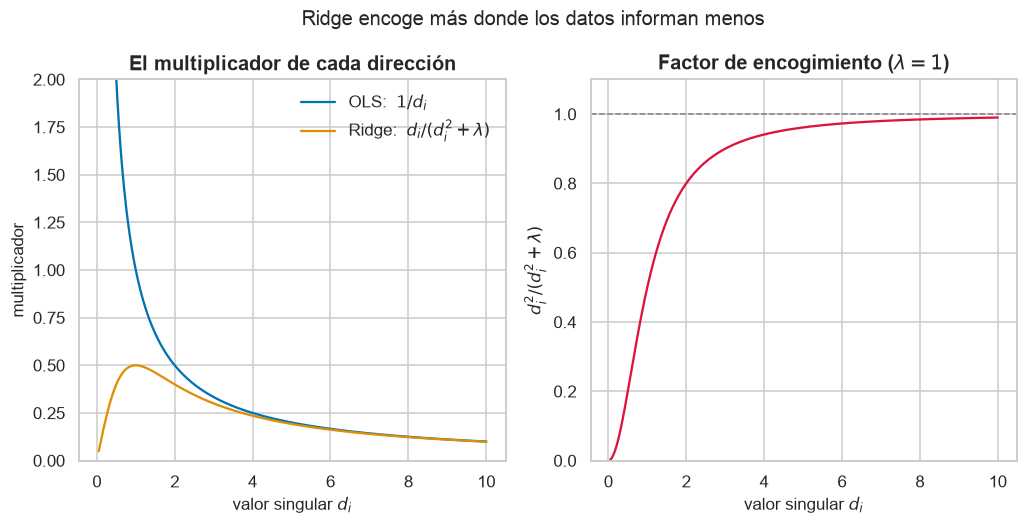

d_i = 1        ->  factor = 5.000e-01
d_i = 0.1      ->  factor = 9.901e-03
d_i = 0.01     ->  factor = 9.999e-05
d_i = 0.0001   ->  factor = 1.000e-08


In [2]:
# La celda 6 de la clase compara los dos multiplicadores. Le agrego el factor de
# encogimiento, que es lo que vuelve comparable a Ridge con lo que vamos a ver de Lasso.
d = np.linspace(0.05, 10, 1000)
lam = 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(d, 1 / d, label=r"OLS:  $1/d_i$")
axes[0].plot(d, d / (d**2 + lam), label=r"Ridge:  $d_i/(d_i^2+\lambda)$")
axes[0].set_ylim(0, 2)
axes[0].set_xlabel(r"valor singular $d_i$")
axes[0].set_ylabel("multiplicador")
axes[0].set_title("El multiplicador de cada dirección")
axes[0].legend()

axes[1].plot(d, d**2 / (d**2 + lam), color="crimson")
axes[1].axhline(1.0, color="gray", ls="--", lw=1)
axes[1].set_ylim(0, 1.1)
axes[1].set_xlabel(r"valor singular $d_i$")
axes[1].set_ylabel(r"$d_i^2/(d_i^2+\lambda)$")
axes[1].set_title(r"Factor de encogimiento ($\lambda = 1$)")

fig.suptitle("Ridge encoge más donde los datos informan menos", y=1.02)
plt.show()

# ¿Llega a cero alguna vez? Miremos el factor para valores singulares muy chicos.
for d_i in [1.0, 0.1, 0.01, 1e-4]:
    print(f"d_i = {d_i:<8g} ->  factor = {d_i**2 / (d_i**2 + lam):.3e}")

Leé el panel izquierdo de derecha a izquierda, que es la dirección en la que se pone interesante. Con $d_i$ grande las dos curvas están pegadas: Ridge y OLS hacen casi lo mismo. A medida que $d_i$ baja, la curva de OLS se dispara hacia infinito —ahí está la inestabilidad— mientras la de Ridge da la vuelta y **baja**. Ridge se comporta bien exactamente donde OLS se descompone.

El panel derecho es el factor de encogimiento, y la tabla de abajo es el punto: el factor se hace chiquísimo ($10^{-8}$ para $d_i = 10^{-4}$) pero **nunca es cero**. Multiplicado por lo que sea, va a dar un número distinto de cero. Si después imprimís $\hat\beta^{ridge}$ vas a ver ocho decimales de basura, no un cero limpio.

Esa es la frustración práctica que Lasso viene a resolver: querés que el modelo te diga *"esta variable no va"*, y Ridge te contesta *"esta variable va con coeficiente 0.0000000031"*. No es lo mismo, y no podés redondear a mano sin inventar un criterio arbitrario.

### ⚠️ Confusión típica

Creer que Ridge selecciona variables si le pones $\lambda$ bien grande. Lo que hace $\lambda \to \infty$ es llevar **todos** los coeficientes a cero a la vez, no seleccionar algunos: te quedás con el modelo que predice siempre $\bar y$. La selección implica dejar algunos coeficientes vivos y otros en cero exacto, y eso Ridge no lo hace para ningún valor finito de $\lambda$.

La segunda confusión, más sutil: pensar que las direcciones singulares que Ridge aplasta son variables. No: son **combinaciones lineales** de variables (las columnas de $V$). Ridge puede aplastar la dirección "lcavol menos lweight" sin apagar ni lcavol ni lweight.


## 3. Lasso: cambiar el cuadrado por el módulo

📓 celdas 7–8 · 📕 ESL §3.4.2 · 📘 Bishop §3.1.4

### La idea en criollo

Volvamos al impuesto. Ridge cobra proporcional al cuadrado del coeficiente; Lasso cobra proporcional a su **valor absoluto**. Es un impuesto de tasa fija: cada unidad de coeficiente cuesta $\lambda$, no importa si es la primera o la décima.

Y acá está el giro. Con tasa fija, bajar un coeficiente de 1 a 0 te ahorra **lo mismo** que bajarlo de 10 a 9: en los dos casos, $\lambda$. Para Ridge el último tramo hasta cero era el más barato de dejar sin recorrer; para Lasso vale exactamente igual que cualquier otro. Entonces, si una variable aporta poco al ajuste, apagarla del todo es negocio.

> **Dónde se rompe la analogía.** Un impuesto real se paga y listo, no cambia lo que hacés con el resto de tus bienes. Acá la penalización y el ajuste se pelean por el **mismo** $\beta$, así que apagar $\beta_3$ le cambia el óptimo a $\beta_5$: si las columnas 3 y 5 están correlacionadas, lo que dejó de explicar la 3 lo va a querer explicar la 5. Ese acoplamiento es la razón de fondo de por qué no hay solución cerrada y de por qué el algoritmo tiene que iterar en ronda en lugar de resolver cada coeficiente una sola vez.

### Formalizándolo

La celda 7 es todo el cambio, y cabe en un exponente:

$$\hat\beta^{lasso} = \arg\min_{\beta} \Big\{ \sum_{i=1}^{N} \big(y_i - \beta_0 - \sum_{j=1}^{p} x_{ij}\beta_j\big)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \Big\}$$

Al lado de Ridge:

| | Penalización | Nombre | Se lee |
|---|---|---|---|
| Ridge | $\lambda \sum_j \beta_j^2$ | norma $L_2$ al cuadrado, $\lambda\|\beta\|_2^2$ | "ele dos" |
| Lasso | $\lambda \sum_j \left|\beta_j\right|$ | norma $L_1$, $\lambda\|\beta\|_1$ | "ele uno" |

*Lasso* es la sigla de *Least Absolute Shrinkage and Selection Operator*, que Tibshirani armó en el paper del Ejercicio 1. Vale leerla despacio porque el nombre contiene la tesis entera: **absolute** (el módulo), **shrinkage** (encoge, como Ridge) y **selection** (y además selecciona, a diferencia de Ridge).

### Lo que ese exponente rompe

$\beta_j^2$ es una parábola: suave, derivable en todo punto, con derivada $2\beta_j$ que vale **cero** en el origen. $|\beta_j|$ es una V: derivable en todo punto **salvo en cero**, con derivada $+1$ a la derecha y $-1$ a la izquierda. En cero no tiene una derivada; tiene un pico.

De esa diferencia salen las dos consecuencias que organizan el resto de la clase:

1. **No hay solución cerrada.** Todo el método de "derivo, igualo a cero, despejo" necesita que la función sea derivable donde está el mínimo. Y el mínimo de Lasso está, muy seguido, justo en los puntos donde la función no es derivable: los que tienen algún $\beta_j = 0$. Por eso no existe ningún $\hat\beta^{lasso} = (\text{algo})^{-1}\mathbf{X}^T\mathbf{y}$ y hay que optimizar numéricamente.
2. **Por eso mismo puede seleccionar.** La derivada del castigo en cero no se apaga: vale $\lambda$ aunque te acerques infinitamente al origen. Hay una fuerza constante empujando hacia cero que no se rinde, y si el ajuste no tiene una fuerza mayor para oponerle, el coeficiente **se queda clavado en cero**. En Ridge la fuerza del castigo se desvanece ($2\lambda\beta_j \to 0$), así que cualquier tironcito del ajuste, por chiquito que sea, alcanza para sacar al coeficiente del cero.

Las dos consecuencias son la misma propiedad —el pico en el origen— vista desde el algoritmo y desde la estadística.

### ¿Por qué nos importa?

Porque el precio y el premio vienen juntos, y conviene saber qué estás comprando. **Pagás** la solución cerrada: ahora hay que iterar, hay tolerancias, hay que elegir un criterio de parada. **Cobrás** un modelo esparso: coeficientes en cero exacto, que es lo mismo que decir un modelo con menos variables.

Ese premio es enorme cuando $p$ es grande. Si tenés 20.000 genes y 300 pacientes, Ridge te devuelve 20.000 coeficientes chiquitos y no sabés por dónde empezar a leer; Lasso te puede devolver 12 distintos de cero. Y si $p > N$, donde OLS ni existe (no hay un único $\hat\beta$), Lasso sigue funcionando.

### Los dos algoritmos

La celda 8 nombra las dos formas de entrenar Lasso:

**1. *Coordinate descent*.** Optimiza un coeficiente a la vez con los demás congelados, en ronda, hasta que nada se mueva. Es el default de `scikit-learn` y es lo que la clase deriva en detalle de acá hasta §7. Gana por dos razones: cada paso de una variable tiene solución **cerrada** (la vamos a deducir), y con muchas variables en cero cada ronda cuesta poquísimo.

**2. LARS (*Least Angle Regression*).** Arranca con todos los coeficientes en cero y va incorporando variables de a una, en el orden en que se vuelven relevantes, ajustando los coeficientes a medida que avanza. Su gracia es que no resuelve el problema para **un** $\lambda$: te construye la **trayectoria completa** de soluciones para todos los $\lambda$ a la vez, aprovechando que esa trayectoria es lineal por tramos. Está en 📕 ESL §3.4.4 y en `sklearn.linear_model.LassoLars`. La clase lo menciona y no lo desarrolla; nosotros tampoco, pero quedate con para qué sirve, porque las trayectorias de coeficientes de §8 son justamente el objeto que LARS calcula de una.


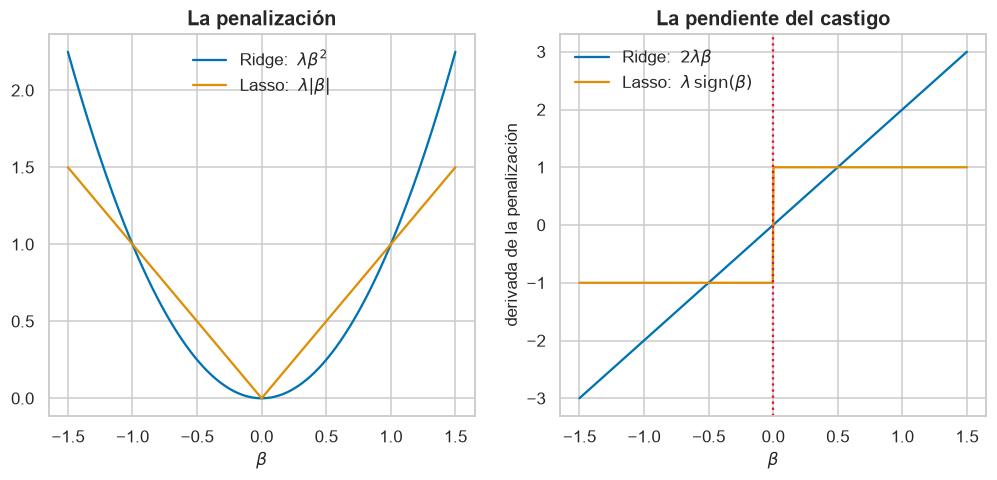

      beta   Ridge: 2*lam*b   Lasso: lam*sign(b)
       0.5         1.000000             1.000000
       0.1         0.200000             1.000000
      0.01         0.020000             1.000000
     1e-06         0.000002             1.000000


In [3]:
# El pico en el origen, que es de donde sale todo lo demás. Miremos las dos
# penalizaciones y sus pendientes cerca de cero.
b = np.linspace(-1.5, 1.5, 1001)
lam = 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(b, lam * b**2, label=r"Ridge:  $\lambda \beta^2$")
axes[0].plot(b, lam * np.abs(b), label=r"Lasso:  $\lambda |\beta|$")
axes[0].set_title("La penalización")
axes[0].set_xlabel(r"$\beta$")
axes[0].legend()

# Pendiente del castigo: cuánta "fuerza hacia cero" siente el coeficiente.
axes[1].plot(b, 2 * lam * b, label=r"Ridge:  $2\lambda\beta$")
axes[1].plot(b, lam * np.sign(b), label=r"Lasso:  $\lambda\,\mathrm{sign}(\beta)$")
axes[1].axvline(0, color="crimson", ls=":", lw=1.5)
axes[1].set_title("La pendiente del castigo")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel("derivada de la penalización")
axes[1].legend()

plt.show()

# La fuerza hacia cero cuando el coeficiente ya es chiquito:
print(f"{'beta':>10} {'Ridge: 2*lam*b':>16} {'Lasso: lam*sign(b)':>20}")
for bb in [0.5, 0.1, 0.01, 1e-6]:
    print(f"{bb:>10g} {2 * lam * bb:>16.6f} {lam * np.sign(bb):>20.6f}")

El panel izquierdo es lo que todo el mundo mira: la V contra la parábola. El panel derecho es el que explica la clase.

Fijate en la curva de Lasso a la derecha: es un escalón. La fuerza que el castigo ejerce sobre el coeficiente vale $\lambda$ **hasta el último momento** y después salta a $-\lambda$; en cero no está definida (ese es el pico, marcado en punteado). La de Ridge, en cambio, pasa por el origen de forma continua: cuando el coeficiente ya es chiquito, la fuerza que lo empuja hacia cero también es chiquita.

La tabla lo dice con números: con $\beta = 10^{-6}$, Ridge lo empuja con una fuerza de $2\times10^{-6}$ —nada— mientras Lasso sigue empujando con $1$. Por eso Ridge deja coeficientes minúsculos pero no nulos, y por eso Lasso los mata.

### ⚠️ Confusión típica

Pensar que "$L_1$ vs $L_2$" es una diferencia de grado, del tipo "Lasso penaliza un poco distinto". No: es una diferencia **cualitativa**. Toda la familia $q > 1$ (que incluye $q=2$, Ridge) da soluciones con todos los coeficientes distintos de cero; $q = 1$ da soluciones esparsas. La frontera está justo en $q=1$, y en §9 vamos a ver por qué ese valor tiene algo especial.

Segunda trampa, esta cuesta plata en el parcial: leer "no hay solución cerrada" como "no se puede resolver exactamente". Se puede, y de hecho la trayectoria completa de soluciones de Lasso es lineal por tramos y LARS la calcula en forma exacta. Lo que no hay es una **fórmula algebraica** en términos de $\mathbf{X}$ y $\mathbf{y}$ que te escupa $\hat\beta$ de una.


## 4. Soft-thresholding: la función que apaga coeficientes

📓 celdas 9–12 · 📕 ESL §3.4.2

La clase dice que *"para entender coordinate descent, conviene entender antes la función soft-thresholding"*, y tiene razón, pero el orden esconde algo: esta función **no se saca de la galera**. Es la solución exacta del problema de una variable que vamos a deducir en §6 y §7. Acá la conocemos; en §7 la vamos a demostrar.

### La idea en criollo

Pensá en el volumen de un equipo de música con un ruido de fondo constante. Vos subís el volumen de la señal, pero el ruido te come los primeros puntos: hasta cierto nivel, no se escucha nada. Pasado ese umbral, empezás a escuchar, pero siempre un poco más bajo de lo que marca la perilla, porque el ruido sigue restando.

*Soft-thresholding* es esa perilla. Le pasás un número $t$ y te devuelve $t$ corrido hacia el cero una distancia $\lambda$; si $t$ no alcanzaba a superar $\lambda$, te devuelve cero.

> **Dónde se rompe la analogía.** El volumen es una sola perilla y va en una sola dirección. La función acá es **simétrica**: si $t$ es negativo, corre hacia el cero desde la izquierda (le **suma** $\lambda$). Y no es que la señal "no se escucha": es que el resultado es **cero exacto**, no un valor chiquito enmascarado. La diferencia importa: acá estamos eligiendo un cero, no perdiendo información en el ruido.

### Formalizándolo

La celda 9 da las dos escrituras:

$$S(t, \lambda) = \text{sign}(t)\,\big(|t| - \lambda\big)_{+} \qquad \text{equivalentemente} \qquad S(t, \lambda) = \text{sign}(t)\,\max\big(0,\; |t| - \lambda\big)$$

La notación $(u)_+$ es la **parte positiva** de $u$: vale $u$ si $u > 0$ y $0$ si $u \le 0$. Es lo mismo que $\max(0, u)$; las dos escrituras son la misma función y conviene reconocer las dos porque los libros alternan.

Leámosla de adentro hacia afuera, que es el orden en que hace las cosas:

1. $|t|$ — me olvido del signo y me quedo con la magnitud.
2. $|t| - \lambda$ — le descuento $\lambda$ a esa magnitud. Este número puede salir negativo.
3. $(\cdot)_+$ — si salió negativo, lo recorto a cero. **Acá se produce la esparsidad.** Este es el único paso de toda la clase que fabrica ceros exactos.
4. $\text{sign}(t) \cdot$ — le devuelvo el signo original a la magnitud recortada.

Escrito por casos, que es como conviene tenerlo para el parcial:

$$S(t,\lambda) = \begin{cases} t - \lambda & \text{si } t > \lambda \\ 0 & \text{si } |t| \le \lambda \\ t + \lambda & \text{si } t < -\lambda \end{cases}$$

Tres detalles que vale la pena registrar:

- El intervalo $[-\lambda, \lambda]$ se colapsa **entero** a cero. Es una **zona muerta** de ancho $2\lambda$.
- Afuera de la zona muerta, la función tiene pendiente 1: es la identidad **desplazada**, no una versión escalada. Un $t$ enorme sale casi intacto (le sacaste $\lambda$ de un número grande: proporcionalmente, nada).
- Nunca cambia el signo ni cruza el cero. Empuja hacia el cero y, en el peor caso, se queda ahí.

### ¿Por qué nos importa?

Porque $S$ es el único lugar de toda la clase donde se fabrican los ceros. Todo lo demás —la geometría del rombo, las trayectorias que tocan el eje, el conteo de variables apagadas— es consecuencia de esos cuatro pasos, y del tercero en particular.

Y porque reaparece sola en otros lados. Cada vez que tengas una pérdida cuadrática más una penalización $L_1$, la solución va a ser un *soft-thresholding* de algo: en compresión de señales, en *denoising* de wavelets, en factorización de matrices con esparsidad. La fórmula es la misma; lo único que cambia es qué es $t$.

### Su prima, la que no es

Conviene distinguirla de la **hard-thresholding**, que hace algo parecido y no es lo mismo:

$$H(t,\lambda) = t \cdot \mathbb{1}\{|t| > \lambda\} = \begin{cases} t & \text{si } |t| > \lambda \\ 0 & \text{si no} \end{cases}$$

La *hard* también apaga los chiquitos, pero a los que sobreviven los deja **intactos**: no los encoge. Es lo que hace la selección de subconjuntos (*best subset selection*, 📕 ESL §3.3): una variable está o no está, y si está va con su coeficiente de OLS. Y es una función **discontinua**, con un salto de tamaño $\lambda$ en el umbral. Esa discontinuidad es la que hace que *best subset* sea un problema combinatorio y horrible de optimizar, mientras que Lasso —cuya solución es la versión *soft*, continua— se resuelve rápido. Lasso es, en cierto sentido, la relajación continua de esa idea.


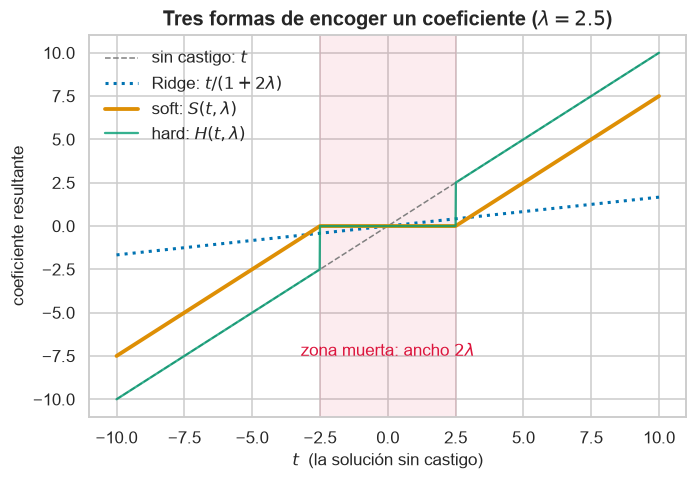

       t       soft      Ridge     hard
    10.0     7.5000     1.6667     10.0
     3.0     0.5000     0.5000      3.0
     2.5     0.0000     0.4167      0.0
     2.0     0.0000     0.3333      0.0
     0.4     0.0000     0.0667      0.0
    -0.4    -0.0000    -0.0667      0.0
    -4.0    -1.5000    -0.6667     -4.0


In [4]:
# La celda 11 de la clase grafica soft-thresholding. Le agrego las dos funciones
# contra las que hay que compararla: la identidad (OLS, sin castigo) y el
# encogimiento de Ridge, que es proporcional en lugar de por corrimiento.
def soft_thresholding(t, lam):
    """S(t, lam) = sign(t) * (|t| - lam)_+ ."""
    return np.sign(t) * np.maximum(np.abs(t) - lam, 0.0)


def hard_thresholding(t, lam):
    return np.where(np.abs(t) > lam, t, 0.0)


lam = 2.5
t = np.linspace(-10, 10, 2001)

fig, ax = plt.subplots()
ax.plot(t, t, ls="--", c="gray", lw=1, label=r"sin castigo: $t$")
ax.plot(t, t / (1 + 2 * lam), ls=":", lw=2, label=r"Ridge: $t/(1+2\lambda)$")
ax.plot(t, soft_thresholding(t, lam), lw=2.5, label=r"soft: $S(t,\lambda)$")
ax.plot(t, hard_thresholding(t, lam), lw=1.5, alpha=0.8, label=r"hard: $H(t,\lambda)$")

# La zona muerta, que es lo único que fabrica ceros.
ax.axvspan(-lam, lam, color="crimson", alpha=0.08)
ax.annotate(r"zona muerta: ancho $2\lambda$", xy=(0, -7.5), ha="center", color="crimson")

ax.set_xlabel(r"$t$  (la solución sin castigo)")
ax.set_ylabel("coeficiente resultante")
ax.set_title(r"Tres formas de encoger un coeficiente ($\lambda = 2.5$)")
ax.legend(loc="upper left")
plt.show()

print(f"{'t':>8} {'soft':>10} {'Ridge':>10} {'hard':>8}")
for tt in [10.0, 3.0, 2.5, 2.0, 0.4, -0.4, -4.0]:
    print(f"{tt:>8.1f} {soft_thresholding(tt, lam):>10.4f} "
          f"{tt / (1 + 2 * lam):>10.4f} {hard_thresholding(tt, lam):>8.1f}")

Tres lecturas del gráfico, y la tabla confirma cada una:

**La zona muerta.** Entre $-2.5$ y $2.5$ la curva *soft* está pegada al eje: da cero exacto. Ridge, en cambio, atraviesa esa zona con una recta de pendiente $1/(1+2\lambda) = 1/6$ que solo toca el cero cuando $t = 0$ exactamente. Con $t = 0.4$, Lasso te devuelve $0$ y Ridge te devuelve $0.0667$. Esa es toda la diferencia entre "esta variable no está en el modelo" y "esta variable está con un coeficiente que no sabés si redondear".

**Corrimiento vs. proporción.** Mirá $t = 10$: *soft* devuelve $7.5$ (le sacó $\lambda = 2.5$, un 25%), Ridge devuelve $1.67$ (lo dividió por 6, le sacó un 83%). Con $t = 3$: *soft* devuelve $0.5$ (le sacó el 83%), Ridge devuelve $0.5$ también. Y con $t=2$: *soft* da $0$, Ridge da $0.33$. O sea: **Lasso castiga proporcionalmente mucho más a los coeficientes chicos, y Ridge a los grandes**. Eso es coherente con el impuesto de tasa fija vs. el progresivo de §3, y es la razón de fondo por la que Lasso mata variables débiles mientras Ridge recorta las fuertes.

**El escalón de la *hard*.** En $t = 2.5$ la curva naranja da un salto de $2.5$ a $0$. Ese salto es la discontinuidad: un cambio infinitesimal en los datos puede hacer que una variable entre al modelo con un coeficiente grande de golpe. La *soft* sale del cero con continuidad. Por eso Lasso es estable y *best subset* no.

### ⚠️ Confusión típica

Confundir el **$t$** de esta función con el $t$ de la formulación con restricción de §9 ($\sum_j |\beta_j| \le t$). Son dos letras $t$ que no tienen nada que ver: acá $t$ es el argumento genérico de $S$ —en el algoritmo va a ser la correlación del residuo parcial con la columna $j$—, y allá $t$ es el tamaño del presupuesto. La cátedra usa la misma letra para las dos cosas; cuando aparezca, mirá qué hay alrededor.

La segunda: creer que $S$ le resta $\lambda$ al coeficiente. Le resta $\lambda$ a su **valor absoluto**, que es otra cosa. Para $t$ negativo, $S$ le **suma** $\lambda$ a $t$ (y eso sigue siendo acercarlo a cero). Si programás `t - lam` sin el `sign`, para los negativos te vas a alejar del cero y todos los coeficientes negativos van a explotar.


## 5. Coordinate descent: un coeficiente a la vez

📓 celdas 13–14 · 📕 ESL §3.4.2

### La idea en criollo

Tenés una mesa con cuatro patas regulables y la querés nivelar. Nadie resuelve eso planteando un sistema de cuatro ecuaciones: agarrás una pata, la regulás hasta que esa esquina quede lo mejor posible, pasás a la siguiente, y cuando terminás la cuarta volvés a la primera —porque al mover las otras tres, la primera te quedó desajustada—. Después de unas rondas, la mesa deja de moverse.

*Coordinate descent* es eso, literalmente. En lugar de buscar el mínimo de una función de $p$ variables, resolvés $p$ problemas de una variable, en ronda, hasta que nada se mueve.

> **Dónde se rompe la analogía.** Con la mesa no tenés garantía de nada: podés quedar dando vueltas para siempre, o "nivelarla" en una posición que no es la mejor. Acá sí hay garantía, y viene de una propiedad específica del problema: la función de costo de Lasso es **convexa**, y se escribe como una parte suave (el $RSS$, que es diferenciable) más una parte separable por coordenada (la penalización $\sum_j |\beta_j|$, donde cada término depende de un solo $\beta_j$). Para funciones con esa estructura, coordinate descent converge al mínimo global. Si la función no fuera convexa —una red neuronal, digamos— el método puede quedarse trabado en un punto que no es el mínimo, y para esos casos no se usa.

### Formalizándolo

Partimos del problema completo (celda 13), ya con todo estandarizado, así que $\beta_0$ desaparece:

$$\hat\beta^{lasso} = \arg\min_{\beta} \Big\{ \sum_{i=1}^{N} \big(y_i - \sum_{j=1}^{p} x_{ij}\beta_j\big)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \Big\}$$

**Paso 1: elegir un $j$ y separarlo del resto.** Sacamos de las dos sumas el término número $j$:

$$\sum_{i=1}^{N} \Big(y_i - \sum_{k \neq j} x_{ik}\beta_k - x_{ij}\beta_j\Big)^2 + \lambda \sum_{k \neq j} |\beta_k| + \lambda|\beta_j|$$

No cambió nada: es la misma expresión con los términos reordenados. Fijate que el índice muto de $j$ a $k$ en las sumas "de los otros", que es la convención estándar para no pisar la letra del que estás mirando.

**Paso 2: congelar los otros.** Acá viene la idea del método. Suponemos que ya tenemos valores $\tilde\beta_k$ para todos los $k \neq j$ —"beta tilde", los valores provisorios de esta ronda— y los tratamos como **constantes conocidas**. La clase aclara de dónde pueden venir: ceros, valores al azar, o el resultado de un OLS o un Ridge previo. Para Lasso lo habitual es arrancar de ceros, y hay un motivo práctico: si $\lambda$ es grande, la mayoría de los coeficientes va a terminar en cero, así que arrancar en cero es arrancar cerca.

Con eso, la función pasa a depender de **una sola** variable:

$$R(\tilde\beta, \beta_j) = \sum_{i=1}^{N} \Big(y_i - \sum_{k \neq j} x_{ik}\tilde\beta_k - x_{ij}\beta_j\Big)^2 + \lambda \sum_{k \neq j} |\tilde\beta_k| + \lambda|\beta_j|$$

La notación $R(\tilde\beta, \beta_j)$ dice justo eso: el primer argumento es el vector de los congelados, el segundo es el único que se mueve.

**Paso 3: reconocer el residuo parcial.** El término

$$y_i - \sum_{k \neq j} x_{ik}\tilde\beta_k$$

es lo que la clase llama **residuo parcial**: el error que te queda si predecís con todas las variables **menos** la $j$. Es "lo que le queda por explicar a $\beta_j$". Y la cuenta ahora es un Lasso de una sola variable: cuánto de ese residuo puede explicar la columna $x_j$, descontando lo que cobra el castigo.

**Paso 4: la solución cerrada.** La celda 14 la da, y es *soft-thresholding*:

$$\hat\beta_j = S\Big(\frac{1}{N}\sum_{i=1}^{N} x_{ij}\big(y_i - \sum_{k\neq j} x_{ik}\tilde\beta_k\big),\; \lambda\Big)$$

Desarmemos el argumento de $S$, que es donde está toda la información:

$$a_j = \frac{1}{N}\sum_{i=1}^{N} x_{ij}\,r_i^{(j)}, \qquad r_i^{(j)} = y_i - \sum_{k\neq j} x_{ik}\tilde\beta_k$$

Eso es el producto interno entre la columna $j$ y el residuo parcial, dividido $N$. Como las columnas están estandarizadas y el residuo tiene media cero, **$a_j$ es la correlación entre la variable $j$ y lo que todavía no está explicado**. Y es, además, exactamente el coeficiente que daría OLS si ajustaras $r^{(j)}$ contra $x_j$ solo (lo vamos a ver caer de la cuenta en §7).

Entonces la actualización se lee en una frase: **"el coeficiente de $j$ es su correlación con el residuo parcial, corrida hacia cero una distancia $\lambda$; y si esa correlación no supera $\lambda$, es cero"**. Ahí está el criterio de selección de Lasso, explícito.

**Paso 5: iterar.** Barrés $j = 1, \dots, p$, actualizando cada coeficiente con la fórmula y usando **siempre los valores más recientes** de los otros (no los de la ronda anterior: los de hace un instante). Cuando una ronda completa casi no mueve nada, pará.

### ¿Por qué nos importa?

Porque convierte un problema sin solución cerrada en una secuencia de problemas **con** solución cerrada. Eso es una técnica que vas a ver reaparecer en toda la materia con otros nombres: dividí el problema en pedazos que sí sabés resolver, y alterná.

Y en la práctica es rapidísimo por una razón específica de Lasso: cuando $\beta_j$ ya está en cero y sigue en cero, no hay nada que actualizar. Con $\lambda$ grande y muchos ceros, cada ronda toca apenas un puñado de coordenadas. Esa es la razón concreta de por qué `sklearn` lo eligió como default.


### ⚠️ Confusión típica

**Actualizar todos los coeficientes "a la vez", usando los valores de la ronda anterior.** Eso no es coordinate descent (es más parecido a un método de Jacobi) y puede no converger. La versión correcta actualiza **en el lugar**: cuando llegás a $j=3$, ya usás los $\beta_1$ y $\beta_2$ nuevos de esta misma ronda. En código, la diferencia está en si escribís sobre el mismo array o armás uno nuevo al costado.

**Recalcular el residuo parcial "restando la columna $j$" con signo equivocado.** El residuo parcial es $r^{(j)} = \mathbf{y} - \mathbf{X}\beta + x_j\beta_j$: al residuo completo le **devolvés** la contribución de $j$, porque justamente querés el error *sin* $j$ en el modelo. Es un `+` donde la intuición te pide un `-`, y es el bug más común de esta implementación.

**Creer que el orden de las coordenadas cambia la solución.** El punto final no depende del orden (la función es convexa y el mínimo es único cuando $\mathbf{X}$ se porta bien), pero el **camino** sí, y por lo tanto la cantidad de iteraciones también. Si el mínimo **no** es único —dos columnas idénticas, por ejemplo— ahí sí el orden puede decidir a cuál de las soluciones equivalentes llegás. Ese escenario es exactamente el Ejercicio 3.

### ❓ La pregunta que quedó abierta

La celda 13 dice que la estimación inicial $\tilde\beta_k$ *"puede ser cero, aleatoria, o el resultado de un cálculo previo de mínimos cuadrados o ridge"* y no vuelve sobre el tema. La pregunta natural es: **¿entonces la solución depende de dónde arranques?**

No. Porque el problema es **convexo**: la función de costo de Lasso es suma del $RSS$ (convexa) y de $\lambda\|\beta\|_1$ (convexa). Una función convexa no tiene mínimos locales que no sean globales, así que no hay "valle equivocado" en el que caer. El punto inicial cambia cuántas iteraciones te toma llegar, no a dónde llegás.

Con una salvedad que vale tener presente: convexa no implica **estrictamente** convexa. Si $\mathbf{X}$ no tiene rango columna completo (dos columnas iguales, o $p > N$), el mínimo puede alcanzarse en todo un conjunto de puntos en lugar de uno solo. Ahí el valor del costo es el mismo para todos, pero el $\hat\beta$ al que llegás **sí** puede depender del punto inicial y del orden de las coordenadas. Es el fenómeno que vas a demostrar a mano en el Ejercicio 3, y la razón de ser del Elastic Net de Zou & Hastie.


## 6. La cuenta, parte 1: de la suma a $\frac{1}{2}\beta_j^2 - a\beta_j + \lambda|\beta_j|$

📓 celdas 15–16 · 📕 ESL §3.4.2

En §5 usamos la fórmula del *soft-thresholding* como dada. Acá arranca la demostración. La clase la hace en dos tramos: primero **limpia** la función hasta dejarla en tres términos (celdas 15–16, esta sección), y después la **minimiza** (celdas 17–21, §7).

La estrategia del primer tramo es una sola idea repetida: **todo lo que no dependa de $\beta_j$ se tira**. Suena obvio y conviene decir por qué se puede: si $f(\beta_j) = g(\beta_j) + c$ con $c$ constante, entonces $f$ y $g$ se minimizan en el **mismo** punto. Cambia el valor del mínimo, no su ubicación. Y a nosotros nos interesa la ubicación.

### La idea en criollo

Pensá en una balanza de dos platos con un montón de objetos apilados en los dos lados. Querés saber de qué lado se inclina. No hace falta pesar todo: todo lo que esté **en los dos platos por igual** se puede sacar sin cambiar el resultado. Sacás lo repetido, y al final te quedan tres objetos en la mano en lugar de cuarenta.

Eso es esta sección. La función de costo tiene un montón de términos, y la mayoría **no depende de $\beta_j$**: ante la pregunta "¿qué $\beta_j$ minimiza?", son peso muerto en los dos platos. Los sacamos uno por uno hasta quedarnos con tres términos.

> **Dónde se rompe la analogía.** De la balanza podés sacar peso igual de los dos lados y el equilibrio no se mueve **ni un poco**: el resultado es idéntico. Acá lo que no se mueve es **dónde** está el mínimo; el **valor** del mínimo sí cambia, y bastante. Si al final de la sección quisieras reportar cuánto vale el costo, tendrías que devolver todo lo que tiraste. No lo vamos a hacer porque no nos interesa el valor: nos interesa el $\beta_j$ que lo alcanza.

### Formalizándolo

**Movida 0: abreviar el residuo parcial.** La clase llama $\tilde y_i$ a la predicción de $y_i$ sin la contribución de $\beta_j$:

$$\tilde y_i = \sum_{k \neq j} x_{ik}\tilde\beta_k$$

Es notación, nada más, pero hace la cuenta legible. Con eso:

$$R(\tilde\beta, \beta_j) = \sum_{i=1}^{N} \big(y_i - \tilde y_i - x_{ij}\beta_j\big)^2 + \lambda\sum_{k\neq j}|\tilde\beta_k| + \lambda|\beta_j|$$

**Movida 1: tirar la penalización de los otros.** El término $\lambda\sum_{k\neq j}|\tilde\beta_k|$ es un número fijo: los $\tilde\beta_k$ están congelados. Afuera.

$$R(\tilde\beta, \beta_j) = \sum_{i=1}^{N} \big(y_i - \tilde y_i - x_{ij}\beta_j\big)^2 + \lambda|\beta_j|$$

**Movida 2: multiplicar por $\frac{1}{2N}$.** Acá hay que ser preciso porque es donde la clase pone su asterisco. Multiplicar **toda** la función por una constante positiva no mueve el mínimo, así que podemos trabajar con $\frac{1}{2N}R$ en lugar de $R$:

$$\frac{1}{2N}R = \frac{1}{2N}\sum_{i=1}^{N}\big(y_i - \tilde y_i - x_{ij}\beta_j\big)^2 + \frac{\lambda}{2N}|\beta_j|$$

y la clase **renombra $\frac{\lambda}{2N}$ como $\lambda$**, escribiendo:

$$R(\tilde\beta, \beta_j) = \frac{1}{2N}\sum_{i=1}^{N}\big(y_i - \tilde y_i - x_{ij}\beta_j\big)^2 + \lambda|\beta_j|$$

Ese renombre es el salto de notación que marcamos en §0: **el $\lambda$ de esta línea es $\frac{1}{2N}$ veces el $\lambda$ de la celda 13**. Es legítimo —la clase lo justifica en la nota al pie: *"cualquier constante multiplicativa que agreguemos en el primer término puede ser eventualmente absorbida en $\lambda$"*— pero si no lo tenés anotado, después no entendés por qué el `alpha` de `sklearn` que te da un resultado razonable es mil veces más chico que el $\lambda$ que esperabas.

¿Y para qué el $\frac{1}{2}$? Para que al derivar el cuadrado aparezca un $2$ que lo cancele y la fórmula final quede limpia. Es cosmética pura, del mismo tipo que el $\frac{1}{2}$ que se le pone al $MSE$ en descenso por gradiente.

**Movida 3: abrir el cuadrado.** Llamemos $u_i = y_i - \tilde y_i$ (el residuo parcial de la observación $i$) y $v_i = x_{ij}$, para que se vea que es un binomio común. Entonces $(u_i - v_i\beta_j)^2 = u_i^2 - 2u_iv_i\beta_j + v_i^2\beta_j^2$, y sumando sobre $i$:

$$R = \underbrace{\frac{1}{2N}\sum_{i} (y_i - \tilde y_i)^2}_{\text{no depende de } \beta_j} \;-\; \frac{1}{N}\sum_i (y_i-\tilde y_i)x_{ij}\,\beta_j \;+\; \frac{1}{2N}\sum_i x_{ij}^2\,\beta_j^2 \;+\; \lambda|\beta_j|$$

(El $2$ del término del medio se comió el $\frac{1}{2}$: $\frac{1}{2N}\cdot 2 = \frac{1}{N}$. Los $\beta_j$ salieron de las sumas porque no dependen de $i$.)

**Movida 4: tirar el primer término.** No depende de $\beta_j$. Afuera.

$$R = \frac{1}{2N}\sum_i x_{ij}^2\,\beta_j^2 \;-\; \frac{1}{N}\sum_i (y_i-\tilde y_i)x_{ij}\,\beta_j \;+\; \lambda|\beta_j|$$

**Movida 5: usar la estandarización.** Acá cobramos el supuesto de §0. Si la columna $j$ está estandarizada, $\sum_i x_{ij}^2 = N$, entonces:

$$\frac{1}{2N}\sum_i x_{ij}^2 = \frac{1}{2N}\cdot N = \frac{1}{2}$$

El coeficiente del término cuadrático es exactamente $\frac{1}{2}$. **Sin estandarizar, acá te quedaba un número distinto para cada columna** y la fórmula final llevaría ese factor colgado (así lo hace `sklearn` internamente, porque no puede asumir nada sobre tus datos).

**Movida 6: bautizar la constante.** El coeficiente del término lineal es un número fijo, calculable con lo que tenemos en la mano:

$$a = \frac{1}{N}\sum_{i=1}^{N}(y_i - \tilde y_i)\,x_{ij}$$

Y llegamos a donde queríamos (celda 16, última línea):

$$\boxed{\;R(\tilde\beta, \beta_j) = \frac{1}{2}\beta_j^2 - a\,\beta_j + \lambda|\beta_j|\;}$$

### ¿Por qué nos importa?

Porque ese despeje convirtió un problema con $N$ observaciones y $p$ variables en **una función escalar de tres términos**, que se puede dibujar en una hoja. Toda la información de los datos se comprimió en un solo número, $a$. El resto de la clase ya no habla de datos: habla de minimizar $\frac{1}{2}\beta^2 - a\beta + \lambda|\beta|$.

Y fijate lo que es $a$: si tiráramos el castigo ($\lambda = 0$), la función sería $\frac{1}{2}\beta_j^2 - a\beta_j$, una parábola con mínimo en $\beta_j = a$. Entonces **$a$ es la solución de mínimos cuadrados** del problema de una variable. Todo lo que vamos a hacer en §7 es preguntarnos cómo la modifica el castigo.


In [5]:
# Movidas 1 a 6, verificadas numéricamente. Si la cuenta está bien, la función
# original y la reducida tienen que diferir en una CONSTANTE (misma forma, mismo
# mínimo, distinta altura). No en cualquier cosa: en una constante.
rng = np.random.default_rng(7)
N, p = 200, 8
X = rng.normal(size=(N, p))
X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.normal(size=N)   # una columna correlacionada
beta_true = np.array([2.0, 0.0, -1.5, 0.0, 0.0, 0.8, 0.0, 0.0])
y = X @ beta_true + rng.normal(scale=0.5, size=N)

# Estandarizamos como pide §0 (std con denominador N) y centramos y.
Xs = (X - X.mean(axis=0)) / X.std(axis=0)
yc = y - y.mean()
print("sum(x_ij^2) por columna:", np.round((Xs**2).sum(axis=0), 6), "  (tienen que dar N =", N, ")")

lam, j = 0.2, 2
beta = np.zeros(p)
beta[[0, 1, 5]] = [1.7, 0.3, 0.5]        # unos betas provisorios cualesquiera

y_tilde = Xs @ beta - Xs[:, j] * beta[j]                  # prediccion sin la columna j
a = Xs[:, j] @ (yc - y_tilde) / N                         # la constante de la movida 6

grid = np.linspace(-2.5, 2.5, 11)
R_original = np.array([(1 / (2 * N)) * np.sum((yc - y_tilde - Xs[:, j] * b) ** 2)
                       + lam * abs(b) for b in grid])
R_reducida = np.array([0.5 * b**2 - a * b + lam * abs(b) for b in grid])

print(f"\na = {a:.6f}")
print("R_original - R_reducida  =", np.round(R_original - R_reducida, 12))
print(f"desvío de esa diferencia = {(R_original - R_reducida).std():.2e}   <- cero numérico")
print(f"argmin original  = {grid[R_original.argmin()]:.4f}")
print(f"argmin reducida  = {grid[R_reducida.argmin()]:.4f}   <- el mismo punto")

sum(x_ij^2) por columna: [200. 200. 200. 200. 200. 200. 200. 200.]   (tienen que dar N = 200 )

a = -1.348300
R_original - R_reducida  = [1.0861465 1.0861465 1.0861465 1.0861465 1.0861465 1.0861465 1.0861465
 1.0861465 1.0861465 1.0861465 1.0861465]
desvío de esa diferencia = 3.90e-16   <- cero numérico
argmin original  = -1.0000
argmin reducida  = -1.0000   <- el mismo punto


La salida dice tres cosas, en orden de importancia creciente.

Primero, la estandarización funcionó: $\sum_i x_{ij}^2 = 200 = N$ para las ocho columnas. Sin eso, la movida 5 no vale.

Segundo, y esto es la verificación: la diferencia entre la función original y la reducida es **el mismo número en los 11 puntos de la grilla** (desvío del orden de $10^{-16}$, que es cero en aritmética de punto flotante). Eso es exactamente lo que predijo la teoría —tiramos constantes, no cosas que dependían de $\beta_j$—. Si hubiéramos tirado algo mal, la diferencia variaría de punto a punto.

Tercero, las dos se minimizan en el mismo lugar de la grilla, que es lo único que nos importaba.

Vale la pena que notes qué **no** dice esta celda: no dice que el mínimo sea $S(a,\lambda)$. Solo dice que simplificamos bien. La minimización viene ahora.

### ⚠️ Confusión típica

Creer que se puede tirar el término $\frac{1}{2N}\sum_i(y_i - \tilde y_i)^2$ "porque es chico". No se tira por chico: se tira porque **no depende de $\beta_j$**. De hecho suele ser el término más grande de los tres. La licencia para tirarlo viene de que es constante *respecto de la variable que estamos optimizando* —y ojo, es constante en esta iteración y para esta coordenada; en cuanto pasás a $j+1$, cambia—.

Y la trampa de escala: si estandarizás con `ddof=1` (el default de `pandas`, denominador $N-1$), entonces $\sum_i x_{ij}^2 = N-1$ y el término cuadrático queda con coeficiente $\frac{N-1}{2N}$ en lugar de $\frac{1}{2}$. Con $N$ grande la diferencia es despreciable; con $N = 10$ te cambia el tercer decimal y te vas a pasar una hora buscando el bug en otra parte.


## 7. La cuenta, parte 2: despejar $\beta_j$ y el agujero en el cero

📓 celdas 17–21 · 📕 ESL §3.4.2

Tenemos que minimizar

$$R(\beta_j) = \frac{1}{2}\beta_j^2 - a\,\beta_j + \lambda|\beta_j|, \qquad a = \frac{1}{N}\sum_{i=1}^{N}(y_i-\tilde y_i)x_{ij}$$

La clase arranca este tramo con una frase que hay que tomar en serio: *"Seamos un poco desprolijos. Supongamos que podemos derivar."* Eso es un aviso de que va a haber un agujero, y que lo van a tapar después. Vamos a hacer las dos cosas: seguir el camino desprolijo (que es el que te van a pedir en el parcial) y después taparlo bien.

### La idea en criollo

Hay dos fuerzas tirando de $\beta_j$. El ajuste tira hacia $a$: quiere que el coeficiente valga la correlación con el residuo parcial. El castigo tira hacia cero, con una fuerza **constante** de intensidad $\lambda$ (esto lo vimos en §3: la pendiente de $\lambda|\beta|$ es $\pm\lambda$, no se desvanece).

Si el ajuste tira más fuerte que $\lambda$, gana el ajuste pero cede $\lambda$ de terreno: el coeficiente queda en $a$ menos $\lambda$ (con el signo que corresponda). Si el ajuste tira con menos de $\lambda$, **no alcanza para mover el coeficiente del cero** y ahí se queda. No es que llegue a un valor chiquito: se queda pegado al cero, porque para salir del cero hay que superar un peaje fijo.

> **Dónde se rompe la analogía.** Con dos fuerzas reales el equilibrio se alcanza donde se cancelan, y si una es mayor el objeto se mueve *todo el camino*. Acá la fuerza del ajuste **no es constante**: crece a medida que $\beta_j$ se aleja de $a$ (es la derivada $\beta_j - a$). El equilibrio no es "gana el más fuerte", es el punto donde las dos se igualan. La imagen de las dos fuerzas sirve para entender el peaje en el cero, no para calcular el óptimo.

### Formalizándolo: el camino desprolijo

Derivamos como si $|\beta_j|$ fuera derivable, usando $\frac{d}{d\beta}|\beta| = \text{sign}(\beta)$, e igualamos a cero (celda 17):

$$\beta_j - a + \lambda\,\text{sign}(\beta_j) = 0$$

Antes de despejar, la observación que hace la clase y que vale oro: **si $\lambda = 0$, queda $\hat\beta_j = a$**. Confirma lo que dijimos al final de §6: $a$ es la solución de mínimos cuadrados univariada, y todo lo que hace el castigo es correrla.

Ahora sí, por casos (celda 18). El problema es que $\text{sign}(\beta_j)$ depende de la respuesta, así que hay que **suponer un signo, despejar, y verificar que la suposición se cumpla**. Es la misma técnica que para resolver una ecuación con módulo en el secundario.

**Caso 1: $\beta_j > 0$.** Entonces $\text{sign}(\beta_j) = 1$ y la ecuación queda $\beta_j - a + \lambda = 0$, o sea:

$$\beta_j = a - \lambda$$

Pero supusimos $\beta_j > 0$, así que esto solo vale si $a - \lambda > 0$, es decir **$a > \lambda$**. Si $a \le \lambda$, la suposición se contradice y este caso no aplica.

**Caso 2: $\beta_j < 0$.** Entonces $\text{sign}(\beta_j) = -1$, la ecuación queda $\beta_j - a - \lambda = 0$:

$$\beta_j = a + \lambda$$

Y para que sea negativo hace falta $a + \lambda < 0$, es decir **$a < -\lambda$**.

Los dos casos juntos son la misma cosa, y así lo señala la clase: en el primero **restamos** $\lambda$ a un número positivo, en el segundo **sumamos** $\lambda$ a un número negativo. Las dos operaciones acercan $\beta_j$ al cero. En una línea:

$$\hat\beta_j = a - \lambda\,\text{sign}(a) = \text{sign}(a)\,(|a| - \lambda) \qquad \text{cuando } |a| > \lambda$$

**Y acá se ve el agujero.** El caso 1 cubre $a > \lambda$, el caso 2 cubre $a < -\lambda$. ¿Qué pasa cuando $|a| \le \lambda$? Ninguno de los dos casos aplica: la ecuación $\beta_j - a + \lambda\,\text{sign}(\beta_j) = 0$ **no tiene solución** con $\beta_j \neq 0$. Y para $\beta_j = 0$ no la podemos ni escribir, porque $\text{sign}(0)$ no está definido y la función no es derivable ahí.

No es que nos falte un caso por vagancia: es que el método de derivar e igualar a cero **no llega** a ese tramo. Ese es el precio de la desprolijidad que la clase anunció.


### ❓ La pregunta que quedó abierta

Las celdas 19 y 21 preguntan exactamente eso —*"¿Qué ocurre si $\left|\frac{1}{N}\sum_i (y_i - \tilde y_i)x_{ij}\right| \le \lambda$?"*— y la celda 21 contesta **"en este caso, la solución es $\beta_j = 0$"**, sin demostrarlo. La celda 20 tiene un gráfico interactivo con sliders (que no se puede ejecutar acá, porque usa `%matplotlib qt`) cuya función era, justamente, **convencerte mirando** en lugar de demostrando.

Demostrémoslo. Hay dos formas, y las dos valen la pena: una elemental que no necesita teoría nueva, y una con la herramienta correcta.

#### Demostración elemental: comparar contra cero y listo

Queremos probar que si $|a| \le \lambda$, entonces $R(\beta) > R(0)$ para todo $\beta \neq 0$. O sea, que cualquier otro punto es peor. Arrancamos de

$$R(\beta) = \frac{1}{2}\beta^2 - a\beta + \lambda|\beta|, \qquad R(0) = 0$$

Separamos según el signo de $\beta$, que es lo único que nos molestaba:

**Si $\beta > 0$:** entonces $|\beta| = \beta$ y

$$R(\beta) = \tfrac{1}{2}\beta^2 - a\beta + \lambda\beta = \tfrac{1}{2}\beta^2 + (\lambda - a)\,\beta$$

Los dos términos son $\ge 0$: el primero porque es un cuadrado (y es $>0$ porque $\beta \neq 0$), y el segundo porque $\beta > 0$ y $\lambda - a \ge 0$ (esto último es exactamente nuestra hipótesis $a \le \lambda$). Entonces $R(\beta) > 0 = R(0)$.

**Si $\beta < 0$:** entonces $|\beta| = -\beta$ y

$$R(\beta) = \tfrac{1}{2}\beta^2 - a\beta - \lambda\beta = \tfrac{1}{2}\beta^2 - (a + \lambda)\,\beta$$

De nuevo el primer término es $>0$. Para el segundo: $\beta < 0$ y $a + \lambda \ge 0$ (por la hipótesis $a \ge -\lambda$), así que $-(a+\lambda)\beta \ge 0$. Entonces $R(\beta) > 0 = R(0)$.

En los dos casos $R(\beta) > R(0)$. Conclusión: con $|a| \le \lambda$, **el cero es el mínimo, y es el único**. Sin subgradientes, sin nada: solo mirar signos.

#### Demostración con la herramienta correcta: subgradientes

La razón por la que la cuenta desprolija falla es que $|\beta|$ no tiene derivada en cero. El objeto que sí existe ahí es el **subgradiente**: en lugar de un número, un **conjunto** de pendientes válidas. Para $|\beta|$ en cero, ese conjunto es todo el intervalo $[-1, 1]$ (cualquier recta con pendiente entre $-1$ y $1$ que pase por el origen queda por debajo de la V):

$$\partial|\beta| = \begin{cases} \{1\} & \beta > 0 \\ [-1, 1] & \beta = 0 \\ \{-1\} & \beta < 0\end{cases}$$

Y la condición de optimalidad para funciones convexas, que generaliza "derivada igual a cero", es: $\beta^*$ es mínimo si y solo si **$0 \in \partial R(\beta^*)$**. Aplicada en $\beta = 0$:

$$\partial R(0) = \{0 - a\} + \lambda[-1,1] = [-a - \lambda,\; -a + \lambda]$$

Para que el $0$ pertenezca a ese intervalo hace falta $-a-\lambda \le 0 \le -a+\lambda$, es decir $-\lambda \le a \le \lambda$:

$$\boxed{\;\beta_j = 0 \iff |a| \le \lambda\;}$$

Que es la respuesta a la pregunta de la celda 19, ahora con demostración. Y fijate que el intervalo $\lambda[-1,1]$ tiene ancho $2\lambda$: es la **misma zona muerta** que vimos en el gráfico de §4. El ancho de la zona muerta y el ancho del subgradiente del módulo en cero son el mismo número, y no es casualidad.

#### Juntando todo

$$\hat\beta_j = \begin{cases} a - \lambda & a > \lambda \\ 0 & |a| \le \lambda \\ a + \lambda & a < -\lambda\end{cases} \;=\; \text{sign}(a)\,\big(|a| - \lambda\big)_+ \;=\; S(a, \lambda)$$

Que es la fórmula de la celda 14, la que en §5 usamos de prestado:

$$\hat\beta_j = S\Big(\frac{1}{N}\sum_{i=1}^{N} x_{ij}\big(y_i - \sum_{k\neq j}x_{ik}\tilde\beta_k\big),\; \lambda\Big)$$

Y *soft-thresholding* dejó de ser una función que apareció de la nada: **es la solución del Lasso de una variable**. Los tres casos de la función son los tres casos de la cuenta, uno por uno.


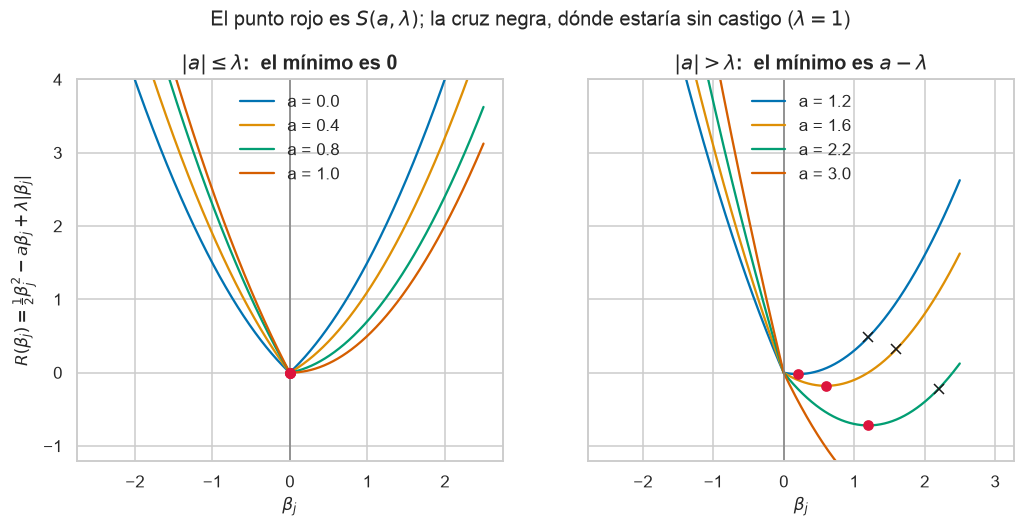

     a   argmin numérico    S(a, lam)
   0.0           0.00000      0.00000
   0.5           0.00000      0.00000
   1.0           0.00000      0.00000
   1.3           0.30000      0.30000
   2.7           1.70000      1.70000
  -1.9          -0.90000     -0.90000


In [6]:
# La celda 20 de la clase era un gráfico con sliders (%matplotlib qt) para mover
# "a" y ver qué pasa con el mínimo. Acá la versión estática: varios valores de "a"
# a la vez, con el mínimo real marcado.
def soft_thresholding(t, lam):
    return np.sign(t) * np.maximum(np.abs(t) - lam, 0.0)


b = np.linspace(-2.5, 2.5, 2001)
lam = 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

# Panel izquierdo: |a| <= lambda  ->  el minimo se queda pegado al cero.
for a in [0.0, 0.4, 0.8, 1.0]:
    R = 0.5 * b**2 - a * b + lam * np.abs(b)
    axes[0].plot(b, R, label=f"a = {a}")
    bs = soft_thresholding(a, lam)
    axes[0].plot([bs], [0.5 * bs**2 - a * bs + lam * abs(bs)], "o", c="crimson", zorder=5)
axes[0].set_title(r"$|a| \leq \lambda$:  el mínimo es 0")

# Panel derecho: |a| > lambda  ->  el minimo se despega, pero corrido lambda.
for a in [1.2, 1.6, 2.2, 3.0]:
    R = 0.5 * b**2 - a * b + lam * np.abs(b)
    axes[1].plot(b, R, label=f"a = {a}")
    bs = soft_thresholding(a, lam)
    axes[1].plot([bs], [0.5 * bs**2 - a * bs + lam * abs(bs)], "o", c="crimson", zorder=5)
    axes[1].plot([a], [0.5 * a**2 - a * a + lam * abs(a)], "x", c="k", ms=7, zorder=5)
axes[1].set_title(r"$|a| > \lambda$:  el mínimo es $a - \lambda$")

for ax in axes:
    ax.axvline(0, color="gray", lw=1)
    ax.set_xlabel(r"$\beta_j$")
    ax.legend(loc="upper center")
axes[0].set_ylabel(r"$R(\beta_j) = \frac{1}{2}\beta_j^2 - a\beta_j + \lambda|\beta_j|$")
axes[0].set_ylim(-1.2, 4)
fig.suptitle(r"El punto rojo es $S(a,\lambda)$; la cruz negra, dónde estaría sin castigo ($\lambda=1$)", y=1.02)
plt.show()

# Chequeo de fuerza bruta: el minimo numerico coincide con la formula?
grilla = np.linspace(-5, 5, 2_000_001)
print(f"{'a':>6} {'argmin numérico':>17} {'S(a, lam)':>12}")
for a in [0.0, 0.5, 1.0, 1.3, 2.7, -1.9]:
    num = grilla[np.argmin(0.5 * grilla**2 - a * grilla + lam * np.abs(grilla))]
    print(f"{a:>6.1f} {num:>17.5f} {soft_thresholding(a, lam):>12.5f}")

Mirá el **pico** de las curvas en $\beta_j = 0$: ahí está el vértice de la V que aporta la penalización. En el panel izquierdo ese pico **es** el punto más bajo de la curva —el mínimo está en el único lugar donde la función no es derivable, que es justo el lugar al que la cuenta desprolija no podía llegar—. Con $a = 1.0$ (el caso límite $|a| = \lambda$) el mínimo sigue en cero, aunque la curva ya está claramente inclinada hacia la derecha.

En el panel derecho el mínimo se despegó. Y fijate en la distancia entre el punto rojo (el mínimo real) y la cruz negra (donde estaría el mínimo sin castigo, o sea en $a$): esa distancia es **siempre $\lambda = 1$**, para $a = 1.2$ igual que para $a = 3.0$. Encogimiento por corrimiento fijo, no por proporción. Es el mismo hecho que la tabla de §4 mostraba con números.

La verificación de fuerza bruta cierra el círculo: buscando el mínimo sobre dos millones de puntos, el resultado coincide con $S(a,\lambda)$ en cinco decimales para todos los $a$ probados, incluido el negativo. La fórmula no es una aproximación: es el mínimo exacto.


### ¿Por qué nos importa?

Porque acá se cierra el círculo de la clase: el *soft-thresholding* que en §4 era "una función que conviene conocer" resultó ser **la solución exacta** del subproblema, y el caso que la cuenta desprolija no podía alcanzar resultó ser el más importante de los tres. Toda la capacidad de Lasso de apagar variables vive en ese caso.

Y porque el patrón de la demostración se repite en toda la optimización moderna. Cada vez que la función que querés minimizar tenga un pico —un módulo, un máximo, una norma $L_1$— "derivar e igualar a cero" te va a dejar un agujero justo en el punto interesante, y la salida va a ser alguna de las dos de arriba: comparar valores a mano, o usar subgradientes. Guardate las dos.

### El algoritmo completo, ahora sí

Ya tenemos todas las piezas. El algoritmo entero es:

1. Estandarizar las columnas de $\mathbf{X}$, centrar $\mathbf{y}$.
2. Arrancar con $\beta = 0$.
3. Repetir hasta que una ronda entera casi no mueva nada:
   - Para cada $j = 1, \dots, p$:
     - $r^{(j)} = \mathbf{y} - \mathbf{X}\beta + x_j\beta_j$  (residuo devolviéndole la contribución de $j$)
     - $a_j = \frac{1}{N}\,x_j^T r^{(j)}$
     - $\beta_j \leftarrow S(a_j, \lambda)$
4. El intercepto se recupera al final: $\hat\beta_0 = \bar y - \sum_j \bar x_j \hat\beta_j$ (si querés los coeficientes en la escala original).

Son diez líneas de código. Escribámoslas.


In [7]:
# Coordinate descent para Lasso, tal como lo derivó la clase.
# Los datos (Xs, yc) son los que armamos en §6: N=200, p=8, columnas 0 y 1
# correlacionadas, y solo tres coeficientes verdaderos distintos de cero.
def lasso_coordinate_descent(X, y, lam, max_rondas=500, tol=1e-9):
    N, p = X.shape
    beta = np.zeros(p)                       # arrancamos en cero (§5, paso 2)
    for ronda in range(1, max_rondas + 1):
        beta_previo = beta.copy()
        for j in range(p):
            # Residuo parcial: al residuo completo le DEVOLVEMOS la contribución de j.
            r_parcial = y - X @ beta + X[:, j] * beta[j]
            a = X[:, j] @ r_parcial / N       # correlación con lo no explicado
            beta[j] = soft_thresholding(a, lam)   # actualización EN EL LUGAR
        if np.max(np.abs(beta - beta_previo)) < tol:
            break
    return beta, ronda


print("coeficientes verdaderos:", beta_true, "\n")
for lam in [0.05, 0.2, 0.5]:
    b_cd, rondas = lasso_coordinate_descent(Xs, yc, lam)
    print(f"λ = {lam:<5} rondas = {rondas:<3} ceros = {int((b_cd == 0).sum())}/8")
    print("   ", np.round(b_cd, 4))

coeficientes verdaderos: [ 2.   0.  -1.5  0.   0.   0.8  0.   0. ] 

λ = 0.05  rondas = 10  ceros = 5/8
    [ 1.8857  0.     -1.3561 -0.      0.      0.7362 -0.      0.    ]
λ = 0.2   rondas = 8   ceros = 5/8
    [ 1.7426  0.     -1.1576 -0.      0.      0.5552 -0.      0.    ]
λ = 0.5   rondas = 8   ceros = 5/8
    [ 1.4565  0.     -0.7606 -0.     -0.      0.1932 -0.      0.    ]


Tres cosas para leer en esa salida.

**Converge rapidísimo.** Ocho o diez rondas para mover ocho coeficientes hasta una tolerancia de $10^{-9}$. No hay tasa de aprendizaje que ajustar, no hay que elegir cuántas épocas: cada paso es exacto y el criterio de parada es "ya no se mueve".

**Los ceros son ceros.** `(b_cd == 0).sum()` usa igualdad **exacta** —el operador `==` sobre floats, que en cualquier otro contexto sería un pecado— y cuenta cinco, para los tres $\lambda$. No son $10^{-9}$: son ceros de verdad, porque salieron del `np.maximum(..., 0.0)` del *soft-thresholding*. Corré ese mismo `==` sobre los coeficientes de Ridge y te va a dar cero coincidencias.

**Recupera la estructura real.** Los coeficientes verdaderos eran `[2, 0, -1.5, 0, 0, 0.8, 0, 0]`: tres distintos de cero. Con $\lambda = 0.2$, Lasso apaga exactamente las cinco variables que sobraban y deja las tres que van, con valores encogidos hacia cero (1.74 en lugar de 2, etc.). Ese sesgo hacia abajo es el precio: es el "shrinkage" del nombre, y es lo que compramos a cambio de menos varianza.

Y notá algo sobre la columna 1, que construimos correlacionada con la 0: su coeficiente verdadero era 0 y Lasso la apagó. Cuando **las dos** columnas correlacionadas tienen coeficiente verdadero distinto de cero, Lasso se pone caprichoso y tiende a elegir una y matar la otra —el fenómeno que el Ejercicio 3 te hace demostrar en el caso extremo—.

#### 🏭 Así se hace en la industria

Nuestras diez líneas no son una versión "de juguete": son el mismo algoritmo que corre `scikit-learn`. Comparemos.


In [8]:
from sklearn.linear_model import Lasso

# El objetivo que minimiza sklearn es  (1/(2N))||y - Xw||^2 + alpha*||w||_1 ,
# o sea exactamente el nuestro con alpha = lambda (el λ de la celda 15 en adelante:
# ver el salto de notación de §0). fit_intercept=False porque ya centramos y.
print(f"{'λ':>6}  {'coordinate descent (a mano)':<45} {'sklearn':<45} {'máx dif':>10}")
for lam in [0.05, 0.2, 0.5]:
    b_mano, _ = lasso_coordinate_descent(Xs, yc, lam)
    b_sk = Lasso(alpha=lam, fit_intercept=False, tol=1e-12, max_iter=100_000).fit(Xs, yc).coef_
    print(f"{lam:>6}  {str(np.round(b_mano, 3)):<45} {str(np.round(b_sk, 3)):<45} "
          f"{np.abs(b_mano - b_sk).max():>10.2e}")

     λ  coordinate descent (a mano)                   sklearn                                          máx dif
  0.05  [ 1.886  0.    -1.356 -0.     0.     0.736 -0.     0.   ] [ 1.886  0.    -1.356 -0.     0.     0.736 -0.     0.   ]   3.24e-12
   0.2  [ 1.743  0.    -1.158 -0.     0.     0.555 -0.     0.   ] [ 1.743  0.    -1.158 -0.     0.     0.555 -0.     0.   ]   5.49e-12
   0.5  [ 1.456  0.    -0.761 -0.    -0.     0.193 -0.     0.   ] [ 1.456  0.    -0.761 -0.    -0.     0.193 -0.     0.   ]   2.15e-12


Coinciden hasta el orden de $10^{-12}$, que es ruido de punto flotante. Dos conclusiones prácticas de esa tabla:

1. La derivación de la clase no es una simplificación pedagógica: es **el** algoritmo. Lo que agrega `sklearn` por encima es ingeniería (no asume que estandarizaste, así que arrastra el $\sum_i x_{ij}^2$ de la movida 5; recorre las coordenadas en un orden inteligente; se saltea las que están en cero; y todo el loop interno está en Cython).
2. **El `alpha` de `sklearn` es el $\lambda$ de la convención $\frac{1}{2N}$**, no el de la celda 7. Si tomás el $\lambda$ de la formulación de ESL y lo pasás como `alpha` tal cual, estás regularizando $2N$ veces más de lo que querías. Con $N = 200$ eso es un factor de 400: la diferencia entre un modelo razonable y uno que te devuelve todos los coeficientes en cero.

### ⚠️ Confusión típica

**Tomar el camino desprolijo como si fuera completo.** Si en el parcial derivás, igualás a cero, hacés los dos casos y entregás, te falta el tercer caso —el más importante, porque es el que produce los ceros y es la razón de ser de Lasso—. La cuenta con los dos casos **no puede** llegar a $\beta_j = 0$: hay que argumentar aparte, con cualquiera de las dos demostraciones de arriba.

**Creer que $\text{sign}(0) = 0$ arregla el problema.** Algunos libros definen así la función signo por comodidad. Si metés $\text{sign}(0)=0$ en $\beta_j - a + \lambda\,\text{sign}(\beta_j) = 0$ evaluada en $\beta_j = 0$, te queda $-a = 0$, o sea $a = 0$: concluirías que el coeficiente es cero **solo** cuando la correlación es exactamente cero. Falso, y borra todo el efecto de selección. La no derivabilidad no se arregla eligiendo un valor para la derivada.

**Pensar que $a$ se calcula una sola vez.** $a_j$ depende de $\tilde\beta_k$ para todo $k \neq j$, así que **cambia en cada iteración y para cada coordenada**. Hay que recalcularlo adentro del loop. Si lo calculás una vez al principio y lo reusás, lo que estás resolviendo es $p$ regresiones simples independientes, que es otro problema (y da otra respuesta, salvo que las columnas sean ortogonales).


## 8. Por qué Lasso selecciona y Ridge no: la geometría

📓 celda 22 · 📕 ESL §3.4.2–§3.4.3

La celda 22 hace **la** pregunta de la clase —*"¿Por qué Lasso selecciona variables y Ridge no?"*— y la contesta con una figura, sin texto. Vale la pena responderla en serio, porque hay tres respuestas y son la misma vista desde tres lugares: el algoritmo, la geometría y los datos.

### La idea en criollo

Imaginate dos formas de repartir un premio entre varios participantes. En la primera, el premio se reparte proporcional al desempeño de cada uno: el que hizo poquito se lleva poquito, pero **se lleva algo**. En la segunda hay un mínimo para cobrar: si no llegás a cierta marca, te vas con las manos vacías, y lo que sobra se reparte entre los que sí llegaron.

Ridge es la primera; Lasso es la segunda. Y fijate en la segunda parte de la regla, que es la que la hace interesante: lo que le sacás a los que no llegaron **no se pierde**, se lo quedan los que sí. Por eso cuando Lasso apaga una variable, los coeficientes de las que sobreviven suben.

> **Dónde se rompe la analogía.** El "desempeño" de cada participante es fijo y se mide una vez; acá la contribución de cada variable **depende de qué otras variables estén prendidas**. Una variable puede parecer inútil con todas las demás presentes y volverse la mejor cuando apagás a su vecina correlacionada. No hay un ranking de desempeño calculable de antemano: por eso el algoritmo tiene que iterar y por eso las trayectorias de §8 tienen quiebres.

### Formalizándolo: tres caminos, la misma razón

Vamos a responder la pregunta desde el algoritmo, desde la geometría y desde los datos, y las tres respuestas van a converger en el mismo hecho: el pico de $|\beta|$ en el origen.

#### Respuesta 1: desde el algoritmo (la que ya demostramos)

Esta la tenemos completa de §7. La actualización de Lasso es $\beta_j \leftarrow S(a_j, \lambda)$, que da **cero exacto** en todo el intervalo $|a_j| \le \lambda$.

Hagamos la misma cuenta para Ridge, que es corta. Con penalización $\lambda\beta_j^2$, la función de una variable es $R(\beta_j) = \frac{1}{2}\beta_j^2 - a\beta_j + \lambda\beta_j^2$, derivable en todo punto. Derivamos e igualamos a cero:

$$\beta_j - a + 2\lambda\beta_j = 0 \;\Longrightarrow\; \hat\beta_j = \frac{a}{1 + 2\lambda}$$

Comparadas lado a lado:

| | Actualización | ¿Cuándo da cero? |
|---|---|---|
| Ridge | $\hat\beta_j = \dfrac{a}{1+2\lambda}$ | solo si $a = 0$ **exactamente** |
| Lasso | $\hat\beta_j = S(a, \lambda)$ | en todo un intervalo, $|a| \le \lambda$ |

Ridge divide; dividir un número distinto de cero por algo finito nunca da cero. Lasso **resta y recorta**; restar puede cruzar el cero, y el recorte lo atrapa ahí. La probabilidad de que $a_j$ caiga **exactamente** en 0 es cero; la de que caiga en un intervalo de ancho $2\lambda$ es perfectamente positiva. Toda la selección de variables está en esa diferencia entre un punto y un intervalo.

#### Respuesta 2: desde la geometría (la figura de la clase)

Esta es la de la figura, y necesita la formulación con restricción que la clase da recién en la celda 23 (§9). Anticipemos la idea: en lugar de "minimizá error más castigo", pensalo como "minimizá el error **sin salirte** de una región". La región es una bola: $\{\beta : \sum_j \beta_j^2 \le t\}$ para Ridge, $\{\beta: \sum_j |\beta_j| \le t\}$ para Lasso.

Y las curvas de nivel del $RSS$ son **elipses** concéntricas alrededor de $\hat\beta^{ols}$, porque el $RSS$ es una cuadrática (lo vimos en la clase 2). Buscar el mínimo dentro de la región es inflar la elipse desde $\hat\beta^{ols}$ hasta que toque la región: el primer punto de contacto es la solución.

Ahora la pregunta es **dónde toca**:

- La bola de Ridge (un círculo, en $p=2$) es **lisa**: no tiene ningún punto privilegiado. La elipse la toca en un punto cualquiera del borde, y un punto cualquiera del círculo tiene sus dos coordenadas distintas de cero.
- La bola de Lasso (un rombo, en $p=2$) tiene **esquinas**, y las esquinas están **sobre los ejes**. Una esquina sobre el eje $\beta_1$ es un punto con $\beta_2 = 0$: un coeficiente apagado. Y una esquina es un blanco gordo: mientras el borde liso solo puede ser tocado tangencialmente en una dirección específica, una esquina "recibe" elipses que vienen de todo un rango de direcciones. Por eso el contacto en una esquina ocurre con probabilidad positiva, no como un caso de medida nula.

En $p$ dimensiones esto escala y se pone mejor: el rombo pasa a ser un politopo con vértices, aristas y caras. Un vértice tiene $p-1$ coordenadas nulas; una arista, $p-2$; y así. Cuanto más "afilada" la parte que toca, más variables apagadas. La bola de Ridge sigue siendo una esfera lisa, sin ningún lugar afilado, para cualquier $p$.


#### 🖼️ La figura de la clase

![Las regiones de restricción de Lasso (rombo) y Ridge (círculo) contra las curvas de nivel del RSS](../../figuras/geometría regularización.png)

Esta es 📕 ESL §3.4.2, y es la figura que hay que poder dibujar de memoria en el parcial. Qué mirar, en este orden:

1. **El punto del centro de las elipses** es $\hat\beta^{ols}$, la solución sin restricción. Ahí el $RSS$ es mínimo y la restricción no se cumple (está afuera de la región).
2. **Las elipses** son las curvas de nivel del $RSS$: todos los $\beta$ que dan el mismo error. Son elipses y no círculos porque $\mathbf{X}^T\mathbf{X}$ no es la identidad; su inclinación y su excentricidad son la correlación entre los predictores. Con predictores muy correlacionados, las elipses se estiran hasta parecer cigarros.
3. **La región azul** es la restricción. El rombo $|\beta_1| + |\beta_2| \le t$ a la izquierda; el disco $\beta_1^2 + \beta_2^2 \le t$ a la derecha.
4. **El punto de contacto** es la solución. En el panel de Lasso está **en un vértice del rombo, sobre un eje**: ahí uno de los dos coeficientes es cero exacto. En el de Ridge está en un punto genérico del borde, con los dos coeficientes distintos de cero.

Y una cosa que la figura **no** muestra y hay que agregar mentalmente: qué pasa si movés $\hat\beta^{ols}$ un poquito. En Ridge, el punto de contacto se desliza suavemente por el círculo. En Lasso, mientras el desplazamiento no sea grande, **el contacto se queda clavado en el mismo vértice**. Esa es la versión geométrica de la zona muerta de §4: un rango entero de datos distintos produce la misma variable apagada.

El límite: acordate que esto es $p=2$. No lo uses para razonar sobre qué pasa con $p = 20.000$ más allá de la intuición de "vértices sobre los ejes"; en dimensión alta la geometría tiene sorpresas (la maldición de la dimensionalidad de 📕 ESL §2.5) y la respuesta 1, la algebraica, es la que sigue valiendo sin asteriscos.

#### Respuesta 3: desde los datos

Las dos respuestas anteriores predicen lo mismo, así que verifiquémoslo: ajustemos Ridge y Lasso sobre los mismos datos para un barrido de $\lambda$ y contemos ceros exactos.


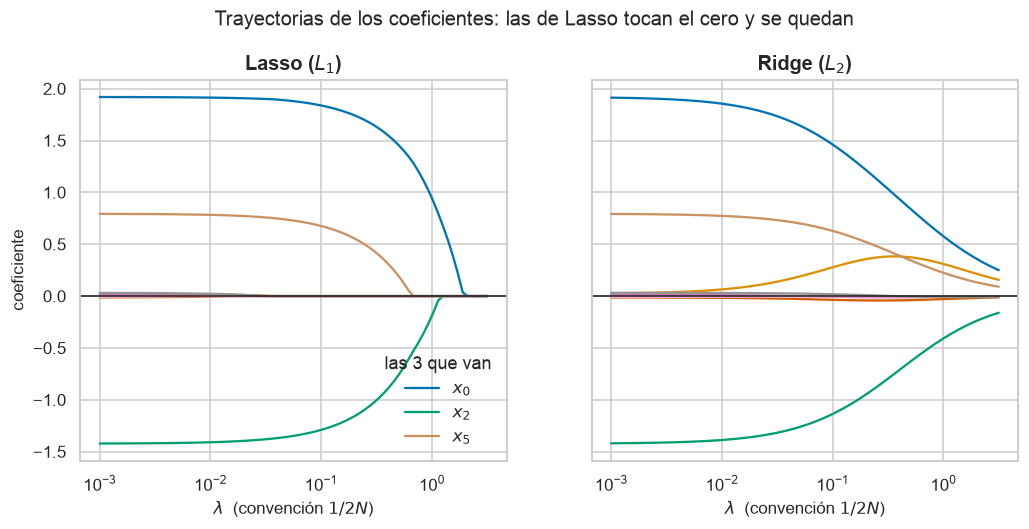

       λ   ceros exactos Lasso   ceros exactos Ridge
  0.0010                     0                     0
  0.0128                     2                     0
  0.0986                     5                     0
  0.4552                     5                     0
  1.5484                     7                     0
  3.1623                     8                     0


In [9]:
from sklearn.linear_model import Ridge

# Barrido de lambda, siempre en la convención (1/2N) de §0.
# Para Ridge, sklearn minimiza ||y - Xw||^2 + alpha*||w||^2 ; dividiendo por 2N eso
# es (1/2N)||y-Xw||^2 + (alpha/2N)||w||^2, así que alpha = 2*N*lambda pone a los
# dos modelos en la misma escala de lambda y la comparación es justa.
lams = np.logspace(-3, 0.5, 80)
coef_lasso = np.array([Lasso(alpha=l, fit_intercept=False, max_iter=100_000)
                       .fit(Xs, yc).coef_ for l in lams])
coef_ridge = np.array([Ridge(alpha=2 * N * l, fit_intercept=False)
                       .fit(Xs, yc).coef_ for l in lams])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, coefs, titulo in [(axes[0], coef_lasso, "Lasso ($L_1$)"),
                          (axes[1], coef_ridge, "Ridge ($L_2$)")]:
    for j in range(p):
        ax.plot(lams, coefs[:, j], label=f"$x_{j}$" if j in (0, 2, 5) else None)
    ax.axhline(0, color="k", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda$  (convención $1/2N$)")
    ax.set_title(titulo)
axes[0].set_ylabel("coeficiente")
axes[0].legend(title="las 3 que van")
fig.suptitle("Trayectorias de los coeficientes: las de Lasso tocan el cero y se quedan", y=1.02)
plt.show()

print(f"{'λ':>8} {'ceros exactos Lasso':>21} {'ceros exactos Ridge':>21}")
for idx in [0, 25, 45, 60, 72, 79]:
    l = lams[idx]
    print(f"{l:>8.4f} {int((coef_lasso[idx] == 0).sum()):>21} "
          f"{int((coef_ridge[idx] == 0).sum()):>21}")

Las dos trayectorias son distintas de una forma que se ve a un metro de distancia.

En el panel de **Lasso**, cada curva llega al cero **en un $\lambda$ finito y concreto**, y de ahí en adelante se queda pegada al eje. Son rectas por tramos con quiebres: cada quiebre es el momento en que alguna otra variable entró o salió del modelo (y esos quiebres son exactamente lo que LARS calcula de forma exacta, sin barrer $\lambda$). En el panel de **Ridge**, las ocho curvas bajan juntas y suavemente, y ninguna toca el eje: se acercan asintóticamente.

La tabla es la versión numérica, y el contraste es total: Lasso pasa de 0 ceros a 8 a medida que sube $\lambda$; Ridge se queda en **0 ceros exactos para todos los $\lambda$**, incluido el más grande del barrido. Es la Propiedad 2 de §2, medida.

Y fijate cuáles sobreviven más tiempo en el panel de Lasso: $x_0$, $x_2$ y $x_5$, que son justo las tres con coeficiente verdadero distinto de cero. El orden en que las variables se apagan es informativo: es una especie de ranking de importancia, y es una de las razones por las que Lasso se usa tanto como herramienta exploratoria.

### ¿Por qué nos importa?

Porque contesta la pregunta práctica de cuándo usar cuál. Si tu problema es **multicolinealidad** y querés coeficientes estables sin descartar nada —todas las variables te parecen plausibles y son pocas—, Ridge. Si tu problema es que tenés **demasiadas variables** y necesitás un modelo que se pueda leer, o si $p > N$, Lasso.

Y porque te da el criterio para no pedirle a cada método lo que no puede dar. Pedirle selección a Ridge es perder el tiempo con umbrales arbitrarios; pedirle a Lasso un reparto estable entre variables correlacionadas es pedirle algo que su geometría no tiene. Cuando querés las dos cosas, la respuesta es Elastic Net, y ahora sabés exactamente por qué.

### ⚠️ Confusión típica

**Leer la trayectoria de Lasso como si fuera monótona.** No lo es necesariamente: un coeficiente puede **crecer** en valor absoluto al subir $\lambda$, o incluso entrar al modelo, salir y volver a entrar. Pasa cuando una variable correlacionada con ella se apaga y le deja el trabajo. Las de Ridge, en cambio, sí se van todas a cero de forma ordenada. Si en un gráfico de trayectorias de Lasso ves una curva que sube, no es un bug.

**Creer que "menos variables" es lo mismo que "mejor modelo".** Lasso te da esparsidad, no te da la verdad. Si dos variables son casi la misma cosa, Lasso elige una **más o menos arbitrariamente** y descarta la otra; con datos nuevos podría elegir la otra. Un coeficiente en cero significa "esta variable no agrega nada *dado el resto de las que quedaron*", no "esta variable no importa". Ese es el punto débil de Lasso y la razón por la que existe Elastic Net (Zou & Hastie 2005), que mezcla las dos penalizaciones y reparte entre las correlacionadas en lugar de elegir.


## 9. Las dos formulaciones y la familia $L_q$

📓 celda 23 · 📕 ESL §3.4.3

La clase cierra con dos generalizaciones en una sola celda: la equivalencia entre la forma lagrangiana y la forma con restricción, y la familia $\lambda\sum_j|\beta_j|^q$ que contiene a Ridge y a Lasso como casos particulares.

### La idea en criollo

Hay dos formas de decirle a alguien que gaste poco. Una: *"tenés 500 pesos, arreglate"* —un techo—. Otra: *"gastá lo que quieras, pero cada peso te lo cobro doble"* —un precio—. Para cualquier techo existe un precio que te lleva a comprar exactamente lo mismo, y viceversa. Son dos interfaces para la misma decisión.

> **Dónde se rompe la analogía.** La correspondencia entre techo y precio no es una función que puedas escribir: **depende de los datos**. Dado un $t$, el $\lambda$ que te lleva a la misma solución existe, pero para encontrarlo hay que resolver el problema. No hay una fórmula $\lambda(t)$ para Lasso. Lo único que sabés es la dirección: $\lambda$ más grande ↔ $t$ más chico.

### Formalizándolo

Lo que veníamos usando se llama la forma **lagrangiana** (por los multiplicadores de Lagrange, que ya vieron en la clase 3). La celda 23 da la forma equivalente **con restricción**:

**Ridge**

$$\hat\beta^{ridge} = \arg\min_{\beta}\Big\{\sum_{i=1}^{N}\big(y_i - \beta_0 - \sum_j x_{ij}\beta_j\big)^2\Big\} \quad \text{sujeto a} \quad \sum_{j=1}^{p}\beta_j^2 \le t$$

**Lasso**

$$\hat\beta^{lasso} = \arg\min_{\beta}\Big\{\sum_{i=1}^{N}\big(y_i - \beta_0 - \sum_j x_{ij}\beta_j\big)^2\Big\} \quad \text{sujeto a} \quad \sum_{j=1}^{p}|\beta_j| \le t$$

La equivalencia dice: **para cada $\lambda \ge 0$ existe un $t$ (y al revés) tal que los dos problemas tienen la misma solución.** La relación es decreciente: $\lambda = 0$ ↔ $t$ tan grande que la restricción no molesta (y ahí $\hat\beta = \hat\beta^{ols}$); $\lambda \to \infty$ ↔ $t \to 0$ (y ahí $\hat\beta = 0$).

¿Para qué dos formulaciones? Porque cada una sirve para algo distinto:

- La **lagrangiana** es la que se optimiza. Es una sola función sin restricciones, que es lo que todo algoritmo quiere.
- La **restringida** es la que se dibuja y la que se interpreta. La figura de §8 solo tiene sentido en esta forma: necesitás la región para que haya algo que tocar. Y el parámetro tiene una lectura directa: $t$ es el presupuesto total de coeficientes.

### ¿Por qué nos importa?

Porque las dos formulaciones son el puente entre las dos mitades de la clase. Todo lo algebraico —la deducción del *soft-thresholding*, el algoritmo, el `alpha` de `sklearn`— vive en la forma lagrangiana. Todo lo visual —el rombo, el círculo, la elipse que toca una esquina— vive en la forma con restricción. Son la misma cosa, y si no sabés que son la misma cosa te parecen dos temas distintos que casualmente se llaman igual.

### La familia general

La celda 23 termina con el paraguas que cubre todo:

$$\hat\beta = \arg\min_{\beta}\Big\{\sum_{i=1}^{N}\big(y_i - \beta_0 - \sum_j x_{ij}\beta_j\big)^2 + \lambda\sum_{j=1}^{p}|\beta_j|^q\Big\}, \qquad q \ge 0$$

El menú:

| $q$ | Nombre | Penaliza | Selecciona | Convexo |
|---|---|---|---|---|
| $0$ | *best subset* | la **cantidad** de coeficientes no nulos ($\|\beta\|_0$) | sí, brutalmente | **no** |
| $0 < q < 1$ | *bridge* | — | sí, más agresivo que Lasso | **no** |
| $1$ | **Lasso** | $\sum_j\|\beta_j\|$ | **sí** | **sí** |
| $q > 1$ | — | — | **no** | sí |
| $2$ | **Ridge** | $\sum_j\beta_j^2$ | no | sí |

Dos observaciones sobre los extremos:

**$q = 0$.** Con la convención $|\beta_j|^0 = 0$ si $\beta_j=0$ y $1$ si no, la penalización cuenta cuántos coeficientes hay prendidos. Es exactamente lo que querés —"usá pocas variables"— y es **computacionalmente intratable**: con $p$ variables hay $2^p$ subconjuntos y no hay forma de evitar explorarlos (por eso *best subset* se usa hasta $p \approx 40$ y no más; 📕 ESL §3.3). La penalización no es convexa, ni siquiera continua.

**$q = 1$ es la frontera.** Y es el punto de toda la tabla. Se puede probar que $\sum_j |\beta_j|^q$ es convexa exactamente para $q \ge 1$, y que la región $\{\sum_j|\beta_j|^q \le t\}$ tiene **esquinas sobre los ejes** exactamente para $q \le 1$. Las dos condiciones se cruzan en un solo valor:

$$q = 1 \;=\; \text{el } q \text{ más chico que todavía es convexo} \;=\; \text{el } q \text{ más grande que todavía tiene esquinas}$$

Lasso es esa intersección. Es el único exponente que te da selección de variables **y** un problema que se puede resolver con garantía de óptimo global. No es una elección estética: es la única celda de la tabla con "sí" en las dos últimas columnas.


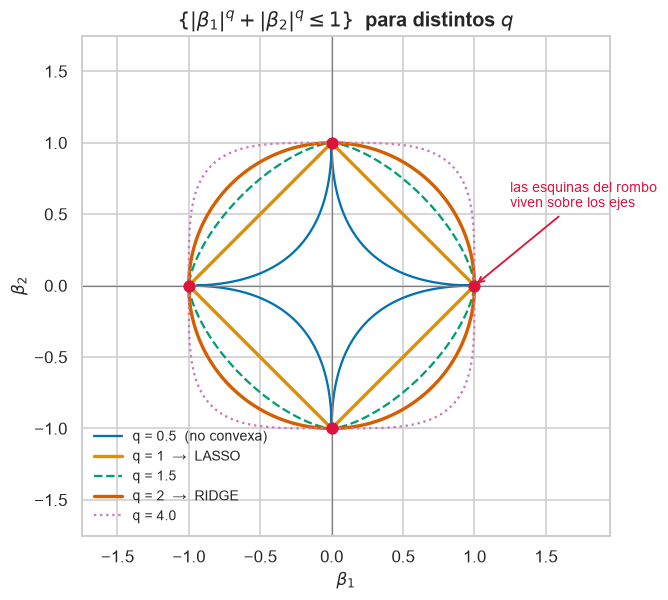

In [10]:
# Las bolas unitarias de L_q en p=2: donde estan las esquinas y donde no.
# Borde de {|b1|^q + |b2|^q = 1}, parametrizado por angulo.
theta = np.linspace(0, 2 * np.pi, 4000)
cos_t, sin_t = np.cos(theta), np.sin(theta)

fig, ax = plt.subplots(figsize=(6.2, 6.2))
for q, estilo in [(0.5, "-"), (1.0, "-"), (1.5, "--"), (2.0, "-"), (4.0, ":")]:
    radio = (np.abs(cos_t) ** q + np.abs(sin_t) ** q) ** (-1.0 / q)
    etiqueta = {0.5: "q = 0.5  (no convexa)", 1.0: "q = 1  →  LASSO",
                2.0: "q = 2  →  RIDGE"}.get(q, f"q = {q}")
    ax.plot(radio * cos_t, radio * sin_t, estilo, lw=2.2 if q in (1.0, 2.0) else 1.5,
            label=etiqueta)

ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.plot([1, -1, 0, 0], [0, 0, 1, -1], "o", c="crimson", ms=7, zorder=5)
ax.annotate("las esquinas del rombo\nviven sobre los ejes", xy=(1, 0), xytext=(1.25, 0.55),
            color="crimson", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))
ax.set_aspect("equal")
ax.set_xlim(-1.75, 1.95)
ax.set_ylim(-1.75, 1.75)
ax.set_xlabel(r"$\beta_1$")
ax.set_ylabel(r"$\beta_2$")
ax.set_title(r"$\{|\beta_1|^q + |\beta_2|^q \leq 1\}$  para distintos $q$")
ax.legend(loc="lower left", fontsize=9)
plt.show()

Recorré el gráfico de afuera hacia adentro, que es como crece $q$.

**$q = 4$** (punteada, la más grande) es casi un cuadrado con las puntas redondeadas: se pega a las diagonales, o sea favorece soluciones donde todos los coeficientes son parecidos. Cero esquinas sobre los ejes.

**$q = 2$**, el círculo: Ridge. Perfectamente liso en todos sus puntos. Ningún lugar donde una elipse "se enganche".

**$q = 1.5$** (rayada) es interesante porque muestra que la transición **no es gradual**: ya está lisa. Basta con pasarse un pelo de $q=1$ para que las esquinas se redondeen y la selección desaparezca. No hay un "medio Lasso" en esta familia.

**$q = 1$**, el rombo: Lasso. Los cuatro puntos rojos son los vértices, y están **sobre los ejes** — $(\pm 1, 0)$ y $(0, \pm 1)$—. Un vértice sobre el eje $\beta_1$ es una solución con $\beta_2 = 0$: variable apagada. Esa es la figura de §8, aislada.

**$q = 0.5$**, la estrella cóncava: las esquinas son más afiladas todavía (selecciona más agresivamente), pero la región ya **no es convexa** —fijate que podés trazar un segmento entre dos puntos de la región que se salga de ella, por ejemplo entre $(1,0)$ y $(0,1)$—. Y una región no convexa significa un problema de optimización con mínimos locales, donde coordinate descent puede terminar en un punto que no es el óptimo, y donde la solución depende de dónde arrancaste.

El gráfico es la tabla de arriba, dibujada: la convexidad se pierde al cruzar $q=1$ hacia abajo, las esquinas se pierden al cruzarlo hacia arriba.

### ⚠️ Confusión típica

**Confundir el $t$ de la restricción con el $\lambda$ de la lagrangiana, o creer que hay una fórmula que los relaciona.** Van en direcciones opuestas ($\lambda$ arriba ↔ $t$ abajo) y la correspondencia depende de los datos. En 📕 ESL las figuras están en términos de $t$ (o de *shrinkage factor*) y las fórmulas en términos de $\lambda$: si mezclás las dos escalas al comparar, los números no van a cerrar.

**Pensar que $q$ es un hiperparámetro más para tunear.** En la práctica nadie barre $q$. Se usa $q=1$ o $q=2$, o la mezcla de los dos que es Elastic Net —$\lambda(\alpha\|\beta\|_1 + (1-\alpha)\|\beta\|_2^2)$—, que es una combinación **convexa de las dos penalizaciones**, no un $q$ intermedio. Y esa distinción es justo lo que muestra el gráfico: la bola de Elastic Net **conserva las esquinas** (porque la parte $L_1$ las aporta) mientras que la de $q=1.5$ las perdió. Por eso Elastic Net selecciona y $q=1.5$ no, aunque las dos estén "entre Ridge y Lasso".


## 🧵 El hilo conductor

Esta clase es el segundo capítulo de una historia que arrancó en la clase 2. Ahí vimos que OLS tiene solución cerrada y que es, en un sentido preciso, óptimo: Gauss–Markov dice que es el mejor entre los estimadores lineales insesgados. En la clase 3 la SVD nos dejó ver *cómo* OLS se descompone por direcciones y en cuáles se vuelve inestable. En la clase 4 aceptamos un trato: meter sesgo a propósito, con $\lambda\|\beta\|_2^2$, para bajar la varianza; Ridge encoge las direcciones de poca información y mantiene la solución cerrada. Hoy hicimos un solo cambio —el cuadrado por el módulo— y todo se reorganizó alrededor de las consecuencias.

La consecuencia técnica es que perdimos la fórmula. $|\beta_j|$ no es derivable en cero, así que el método de "derivo, igualo, despejo" no cierra, y hay que optimizar numéricamente. Ahí entró coordinate descent con una estrategia que conviene guardar como patrón general: **si el problema de $p$ variables no lo sabés resolver, resolvé $p$ problemas de una variable, en ronda, y aprovechá que la convexidad te garantiza que llegás al mismo lugar**. Y el problema de una variable sí tiene solución cerrada: es *soft-thresholding*, que dedujimos entera en §6 y §7, incluido el caso $\beta_j = 0$ que la clase dejó sin demostrar y que resulta ser el más importante.

La consecuencia estadística es que ganamos selección de variables. Y la vimos desde tres lugares que resultaron ser el mismo: la zona muerta de ancho $2\lambda$ en la fórmula, los vértices del rombo sobre los ejes en la figura, y las trayectorias que tocan el cero y se quedan en los datos. La raíz de las tres es el pico de $|\beta|$ en el origen, donde la penalización tiene pendiente $\lambda$ en lugar de $0$. Toda la clase se puede resumir en que ese pico existe.

De acá, tres hilos se abren. Uno es **cómo elegir $\lambda$**, que esta clase dejó abierto a propósito y que el Ejercicio 2 te va a hacer enfrentar: se elige por validación cruzada, que es 📕 ESL §7.10, y necesita el marco de sesgo–varianza que viene en las próximas clases. Otro es qué hacer con **variables correlacionadas**, donde Lasso elige caprichosamente: ese es el Ejercicio 3 en su versión extrema y el motivo del Elastic Net de Zou & Hastie. El tercero es que $\lambda$ es el primer **hiperparámetro** de verdad de la materia —algo que el modelo no aprende de los datos y que hay que elegir desde afuera—, y ese problema, el de elegir la complejidad del modelo, es el tema del resto de la cursada.

## ✅ Autoevaluación

**1.** ¿Por qué $\beta_0$ no aparece en la suma de la penalización?

<details><summary>Respuesta</summary>

Porque $\beta_0$ no mide complejidad: mide dónde está el centro de $\mathbf{y}$. Penalizarlo empujaría las predicciones hacia cero en lugar de hacia el promedio de los datos, lo que convertiría al modelo en peor sin ganar nada en varianza. Además, el resultado dependería de la unidad en la que medís $\mathbf{y}$: si pasás de pesos a miles de pesos, el $\beta_0$ óptimo cambia de escala y la penalización que le cobrás cambia de golpe, así que el modelo dejaría de ser equivariante ante un cambio de unidades. La solución práctica es centrar $\mathbf{y}$ y las columnas de $\mathbf{X}$: con todo centrado el intercepto óptimo es cero y desaparece de la cuenta, y al final lo recuperás con $\hat\beta_0 = \bar y - \sum_j \bar x_j\hat\beta_j$.

</details>

**2.** Calculá $S(t, \lambda)$ para $\lambda = 2$ y $t = 5,\; 2,\; -0.5,\; -7$.

<details><summary>Respuesta</summary>

$S(5,2) = 3$ (magnitud $5 > 2$, le resto $2$, signo positivo). $S(2,2) = 0$ (magnitud igual al umbral: $(2-2)_+ = 0$, cae en la zona muerta, que es cerrada). $S(-0.5, 2) = 0$ (magnitud $0.5 \le 2$). $S(-7,2) = -5$ (magnitud $7 > 2$, magnitud recortada $5$, signo negativo: $-5$).

El error clásico es el último: escribir $-7 - 2 = -9$. La función acerca al cero, nunca aleja. Para negativos, "acercar" significa **sumar** $\lambda$.

</details>

**3.** Coordinate descent llega a la coordenada $j$ y el residuo parcial resulta ortogonal a la columna $x_j$. ¿Qué pasa con $\beta_j$, y para qué valores de $\lambda$?

<details><summary>Respuesta</summary>

Ortogonal significa $x_j^T r^{(j)} = 0$, entonces $a_j = 0$, y $S(0,\lambda) = 0$ para **todo** $\lambda \ge 0$, incluido $\lambda = 0$. El coeficiente se apaga.

Lo interesante es que acá Lasso y Ridge coinciden: la actualización de Ridge, $a/(1+2\lambda)$, también da cero. Es el único caso en que Ridge produce un cero exacto, y por eso mismo es un caso de medida nula: con datos reales, $a_j$ jamás vale exactamente cero. La diferencia entre los dos métodos no está en este caso: está en el intervalo entero alrededor de él.

</details>

**4.** Tenés $N = 100$ y estandarizás las columnas. Con la formulación de la celda 7 (sin el $\frac{1}{2N}$) querés el equivalente a `alpha=0.1` de `sklearn.linear_model.Lasso`. ¿Qué $\lambda$ va en la formulación de la celda 7?

<details><summary>Respuesta</summary>

El `alpha` de `sklearn` es el $\lambda$ de la convención $\frac{1}{2N}$, y la traducción de §0 es $\lambda_{\text{celda 15}} = \lambda_{\text{celda 7}}/(2N)$. Despejando: $\lambda_{\text{celda 7}} = 2N \cdot \text{alpha} = 2 \cdot 100 \cdot 0.1 = 20$.

Que la respuesta sea 200 veces más grande que el `alpha` es la razón por la que este salto de notación cuesta caro. Si tomás un $\lambda$ de un ejercicio de ESL y lo metés como `alpha` sin convertir, estás pidiendo $2N$ veces más regularización de la que creés: con $N$ grande, todos los coeficientes en cero.

</details>

**5.** Para $\lambda$ grande, Ridge deja todos los coeficientes distintos de cero y Lasso deja algunos en cero exacto. Mostralo con las dos actualizaciones de coordinate descent, sin apelar a la geometría.

<details><summary>Respuesta</summary>

Ridge: $\hat\beta_j = \dfrac{a_j}{1+2\lambda}$. Es una división. Si $a_j \neq 0$ y $\lambda$ es finito, el resultado es distinto de cero, por más chico que sea. Hacen falta $\lambda = \infty$ o $a_j = 0$ para obtener cero.

Lasso: $\hat\beta_j = \text{sign}(a_j)(|a_j| - \lambda)_+$. Es una resta seguida de un recorte. En cuanto $\lambda \ge |a_j|$, la resta da algo $\le 0$ y el recorte lo manda a cero exacto. El umbral es finito y calculable: $\lambda = |a_j|$.

Uno escala, el otro traslada y trunca. Solo la segunda operación puede producir un cero a partir de un número que no era cero.

</details>

**6.** ¿Por qué la derivación desprolija de la celda 18 (derivar, igualar a cero, dos casos) **no puede** llegar al resultado $\beta_j = 0$? No alcanza con decir "porque $|\beta|$ no es derivable en cero": explicá dónde exactamente se rompe.

<details><summary>Respuesta</summary>

La ecuación $\beta_j - a + \lambda\,\text{sign}(\beta_j) = 0$ es la condición de derivada nula, y solo tiene sentido en los puntos donde la derivada existe, o sea $\beta_j \neq 0$. Entonces, por construcción, sus soluciones nunca pueden ser $\beta_j = 0$: el punto está excluido del dominio de la ecuación.

Peor: cuando $|a| \le \lambda$, esa ecuación **no tiene ninguna solución**. El caso $\beta_j>0$ pide $a > \lambda$ y el caso $\beta_j<0$ pide $a < -\lambda$; con $|a| \le \lambda$ ninguna de las dos se cumple y ambos casos se autodescartan. Y una función continua en un intervalo cerrado y coerciva como $R$ **tiene** mínimo. Si la condición de derivada nula no lo encuentra, es porque el mínimo está en un punto donde la derivada no existe: el cero. La ausencia de solución es, en sí misma, la pista de dónde está el mínimo.

Para cerrarlo hace falta un argumento distinto: comparar $R(\beta)$ contra $R(0)$ directamente (la demostración elemental de §7) o usar subgradientes.

</details>

**7.** Tenés dos columnas **idénticas**, $x_1 = x_2$, las dos relevantes. ¿Qué hace coordinate descent? ¿Y qué te dice eso sobre la unicidad de $\hat\beta^{lasso}$?

<details><summary>Respuesta</summary>

Si $x_1 = x_2$, cualquier reparto $(\beta_1, \beta_2)$ que mantenga la suma $\beta_1 + \beta_2 = c$ **fija** produce exactamente las mismas predicciones, así que el mismo $RSS$. La penalización $|\beta_1| + |\beta_2|$ tampoco los distingue: vale $|c|$ para cualquier reparto **con los dos del mismo signo** (por desigualdad triangular, un reparto con signos opuestos paga más). Entonces todo un segmento de puntos alcanza el mismo mínimo: $\hat\beta^{lasso}$ **no es único**.

Coordinate descent va a converger a uno de esos puntos, y a cuál depende del orden en que recorra las coordenadas y de dónde arrancó. Con Ridge esto no pasa: la penalización $\beta_1^2+\beta_2^2$ sujeta a suma fija tiene un único mínimo, en $\beta_1 = \beta_2 = c/2$ (reparte en partes iguales), así que la solución de Ridge **sí** es única y simétrica.

Este es el Ejercicio 3 con otra ropa, y también el motivo de Elastic Net: agregarle una pizca de $L_2$ a la penalización $L_1$ vuelve el problema estrictamente convexo, recupera la unicidad y reparte entre las correlacionadas.

</details>

**8.** ¿Por qué $q = 1$ y no $q = 0.9$? Los dos dan esquinas y $0.9$ selecciona más agresivamente.

<details><summary>Respuesta</summary>

Por convexidad. $\sum_j|\beta_j|^q$ es convexa exactamente para $q \ge 1$; con $q = 0.9$ la región de restricción ya es cóncava (mirá la curva $q=0.5$ del gráfico de §9: el segmento entre $(1,0)$ y $(0,1)$ se sale de la región).

Y sin convexidad perdés todo lo que hace usable a Lasso: puede haber mínimos locales, así que el resultado depende del punto inicial; coordinate descent ya no tiene garantía de converger al óptimo global; y no hay certificado de optimalidad. Ganás un poco de esparsidad y pagás con un problema que no sabés resolver.

$q=1$ es el único valor donde las dos cosas que querés conviven: el más chico que sigue siendo convexo, el más grande que todavía tiene esquinas.

</details>

**9.** En el gráfico de trayectorias de §8, ¿qué significa el $\lambda$ en el que una curva de Lasso toca el cero? ¿Se puede calcular a mano el $\lambda$ a partir del cual **todos** los coeficientes son cero?

<details><summary>Respuesta</summary>

Ese $\lambda$ es el punto en que la variable sale del modelo: para valores mayores, su correlación con el residuo parcial ya no supera el peaje.

Para el $\lambda$ que apaga todo, sí, y sale de la condición de optimalidad. Si $\beta = 0$ es la solución, el residuo parcial de cada coordenada es $\mathbf{y}$ entero, así que $a_j = \frac{1}{N}x_j^T\mathbf{y}$ para todo $j$. Y $\beta_j = 0$ requiere $|a_j| \le \lambda$ para **todas** las coordenadas a la vez. Entonces

$$\lambda_{\max} = \max_j \Big|\frac{1}{N}x_j^T\mathbf{y}\Big|$$

Para cualquier $\lambda \ge \lambda_{\max}$, el vector cero cumple la condición de optimalidad y la solución es $\hat\beta = 0$. Es exactamente lo que usa `sklearn` para construir su grilla de `alphas` cuando no le pasás una: arranca en $\lambda_{\max}$, donde está garantizado que todo es cero, y baja.

</details>

**10.** Estandarizaste usando `X.std(ddof=1)` (denominador $N-1$) en lugar de $N$, con $N=20$. Implementás coordinate descent con la fórmula $\beta_j \leftarrow S(a_j,\lambda)$ tal cual. ¿Qué queda mal, y cuánto?

<details><summary>Respuesta</summary>

Con `ddof=1`, $\frac{1}{N}\sum_i x_{ij}^2 = \frac{N-1}{N}$ en lugar de $1$, así que en la movida 5 de §6 el término cuadrático queda con coeficiente $\frac{N-1}{2N}$ y no $\frac{1}{2}$. Rehaciendo la cuenta con un coeficiente genérico $\frac{c}{2}$ (donde $c = \frac{1}{N}\sum_i x_{ij}^2$), la actualización correcta es

$$\beta_j = \frac{1}{c}\,S(a_j, \lambda)$$

o sea que usar la fórmula sin el $\frac{1}{c}$ te deja todos los coeficientes escalados por $c = \frac{N-1}{N}$. Con $N = 20$ eso es $0.95$: un 5% de error sistemático, todos los coeficientes un poco chicos. Suficiente para que no te cierre contra `sklearn` y demasiado poco para que sospeches de la estandarización.

Lo que **no** cambia es qué coeficientes son cero: un factor positivo no mueve el umbral, porque $\frac{1}{c}S(a,\lambda) = 0 \iff S(a,\lambda)=0$. El patrón de esparsidad sobrevive; los valores, no.

</details>

## 🎯 Centros para los ejercicios

### Ejercicio 1 — Leer el paper original de Tibshirani (1996)

- **De qué va realmente:** ver de dónde salió todo esto y con qué se comparaba en su momento. El paper es de 1996 y su contribución no fue la penalización $L_1$ en abstracto, sino el argumento de que **da selección de variables y es computable**, contra *best subset* (correcta pero intratable) y *stepwise* (barata pero inestable). Leelo con esa pregunta en la cabeza: ¿contra qué está compitiendo?
- **Por dónde arrancar:** por el abstract y la sección 2 (la definición), que vas a reconocer línea por línea después de esta clase. Después saltá directo a la sección de la **interpretación geométrica** y comparala con la figura de §8, y a la de **ortonormal design**, donde la solución se reduce exactamente al *soft-thresholding* que dedujimos. Las secciones de cálculo del paper usan un algoritmo distinto del que vimos (coordinate descent para Lasso es posterior, de Friedman, Hastie y Tibshirani); no te trabes ahí.
- **Con qué chequear:** que puedas responder tres cosas en tus palabras: qué significa la sigla y por qué cada palabra está ahí; qué ejemplo usa el paper para mostrar que Lasso mejora a OLS; y qué dice sobre cómo elegir el parámetro de regularización (adelanto: no es "a ojo").
- **⚠️ Dónde te vas a trabar:** en la notación. El paper usa $t$ para el presupuesto (la formulación con restricción de §9), no $\lambda$, así que todas sus fórmulas están en la otra interfaz. Y define el *standardized parameter* $s = t/\sum_j|\hat\beta_j^{ols}|$, que va de 0 a 1 y es lo que aparece en los ejes de sus figuras. Traducí eso a $\lambda$ mentalmente —$s$ chico ↔ $\lambda$ grande— antes de intentar comparar con nada de esta notebook.

### Ejercicio 2 — Lasso sobre Prostate Cancer y la elección de $\lambda$

- **De qué va realmente:** son dos preguntas pegadas y conviene separarlas. La primera es de implementación y reproducción: ajustar Lasso y llegar a los números de la tabla de ESL. La segunda es la que la clase dejó abierta a propósito y es la más importante de las dos: **¿de dónde sale $\lambda$?** No sale de los datos de entrenamiento —ahí el mejor $\lambda$ es siempre 0—, así que hace falta un mecanismo nuevo. Ese mecanismo es validación cruzada (📕 ESL §7.10), y la pregunta del enunciado te está empujando a inventarlo antes de que te lo enseñen.
- **Por dónde arrancar:** por el preprocesamiento, y hacelo antes de tocar cualquier modelo. `src/datasets/prostate.data` está separado por tabulaciones, tiene una columna de índice y una columna `train` con T/F que define la partición que usa el libro. Estandarizá las columnas de predictores y centrá `lpsa` **usando solo el conjunto de entrenamiento** (la media y el desvío del test no los podés mirar), y verificá con un `print` que $\sum_i x_{ij}^2 = N$ antes de seguir. Recién ahí ajustá, y arrancá con un solo $\lambda$ para ver que todo el andamiaje funciona.
- **Con qué chequear:** tenés tres chequeos independientes, usalos en este orden. **Uno:** tu implementación a mano contra `sklearn.linear_model.Lasso` con el mismo $\lambda$, como hicimos en §7 — si no coinciden, el problema es tuyo y no del dataset. **Dos:** con $\lambda \to 0$ los coeficientes tienen que tender a los de OLS de la clase 2 (y a la Tabla 3.2 de ESL). **Tres:** el patrón de ceros contra la columna de Lasso de la tabla del libro: cuáles variables sobreviven importa más que el tercer decimal. Para la pregunta de "¿qué nivel de regularización se usó?", el camino es al revés: barré $\lambda$, mirá para cuál tu vector de coeficientes se parece más al de la tabla, y acordate del factor $2N$ de §0 antes de reportar el número.
- **⚠️ Dónde te vas a trabar:** en dos lugares. El primero, la escala de $\lambda$: vas a probar el valor que sale de la tabla, te van a dar todos ceros, y vas a pensar que tu código está roto. No está roto; es la conversión de §0. El segundo, en el momento de elegir $\lambda$ por validación cruzada: la tentación es partir el conjunto de test para elegirlo. Si hacés eso, el error de test que reportás ya no mide nada, porque usaste el test para decidir. La partición tiene que salir de adentro del entrenamiento.

### Ejercicio 3 — Ridge reparte, Lasso elige: el caso $n = p = 2$

- **De qué va realmente:** de tocar con la mano la diferencia que §8 mostró con dibujos. Con dos columnas idénticas, Ridge tiene solución única y simétrica, y Lasso tiene **infinitas** soluciones. Y la pregunta de fondo, la que se responde sola cuando terminás las cuatro partes: ¿qué propiedad de cada penalización produce cada comportamiento? (Pista de a dónde llegás: una es estrictamente convexa en la dirección $\beta_1 - \beta_2$ y la otra es **plana** en esa dirección.)
- **Por dónde arrancar:** escribiendo los datos explícitamente con una sola letra. Las hipótesis del enunciado ($x_{11}=x_{12}$, $x_{21}=x_{22}$, $x_{11}+x_{21}=0$, $y_1+y_2=0$) dejan **todo** en función de un solo número: poné $x_{11}=x_{12}=x$ y deducí quién es cada entrada de la matriz y de $\mathbf{y}$. Cuando tengas la matriz de $2\times 2$ escrita con esa única letra, escribí el $RSS$ y vas a ver que las dos observaciones aportan el **mismo** término. A partir de ahí es una función de dos variables que cabe en dos líneas.
- **Con qué chequear:** para la parte de Ridge, que el $\hat\beta$ que obtenés coincida con $(\mathbf{X}^T\mathbf{X}+\lambda I)^{-1}\mathbf{X}^T\mathbf{y}$ calculado numéricamente con NumPy para un $x$ y un $\lambda$ concretos —y que al invertir los roles de las dos columnas te dé lo mismo, que es la simetría que el enunciado te pide probar—. Para la parte de Lasso: una vez que describas el conjunto de soluciones, tomá **dos** puntos distintos de ese conjunto, evaluá la función objetivo en los dos y verificá que dan **el mismo** valor. Ese es el certificado de que hay más de una solución. Y ojo con la frontera del conjunto: chequeá también un punto con signos opuestos, para ver que ese paga más.
- **⚠️ Dónde te vas a trabar:** en el módulo. Al escribir el objetivo de Lasso te va a quedar $|\beta_1| + |\beta_2|$ y vas a querer derivar; no se puede, por todo lo de §7. El camino es notar que el $RSS$ depende **solo de la suma** $\beta_1+\beta_2$, fijar esa suma en el valor que minimiza el $RSS$, y preguntarte cuál es el mínimo de $|\beta_1|+|\beta_2|$ entre todos los repartos con esa suma fija. Ahí la desigualdad triangular te da la respuesta de una, sin derivar nada, y también te dice por qué el conjunto de soluciones es un segmento y no una recta entera.
